# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [2]:
#!rm SUSY.csv

In [3]:
#!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 3609384
-rw-r--r--  1 kevinnguyen  staff   401K Mar 28 14:14 Lab.7.ipynb
-rw-r--r--  1 kevinnguyen  staff     0B Mar 28 14:04 SUSY-small.csv
-rw-r--r--  1 kevinnguyen  staff   880M Mar 28 14:06 SUSY.csv.gz
-rw-r--r--  1 kevinnguyen  staff   880M Mar 28 14:04 susy.zip


The data is provided as a comma separated file.

In [1]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

head: SUSY.csv: No such file or directory


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [2]:
!ls -lh

total 2168
-rw-r--r--  1 kevinnguyen  staff   1.1M Mar 28 15:13 Lab.7.ipynb
-rw-r--r--  1 kevinnguyen  staff     0B Mar 28 14:14 SUSY-small.csv
-rw-r--r--  1 kevinnguyen  staff    72B Mar 28 15:14 Untitled.ipynb


We see that we have 5 million datapoints.

In [3]:
!wc -l SUSY.csv

wc: SUSY.csv: open: No such file or directory


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [4]:
!head -500000 SUSY.csv > SUSY-small.csv

head: SUSY.csv: No such file or directory


In [5]:
ls -lh

total 2168
-rw-r--r--  1 kevinnguyen  staff   1.1M Mar 28 15:13 Lab.7.ipynb
-rw-r--r--  1 kevinnguyen  staff     0B Apr 10 16:32 SUSY-small.csv
-rw-r--r--  1 kevinnguyen  staff    72B Mar 28 15:14 Untitled.ipynb


In [6]:
! wc -l SUSY-small.csv

       0 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [16]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [17]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [18]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [19]:
FeatureNames

['dPhi_r_b',
 'MET_rel',
 'MT2',
 'M_Delta_R',
 'axial_MET',
 'S_R',
 'R',
 'cos_theta_r1',
 'M_TR_2',
 'M_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [21]:
filename = "SUSY.csv.gz"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [22]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [23]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


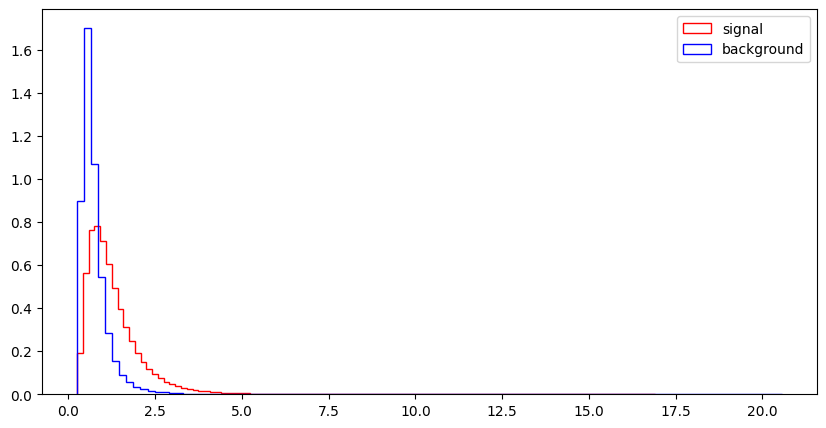

l_1_eta


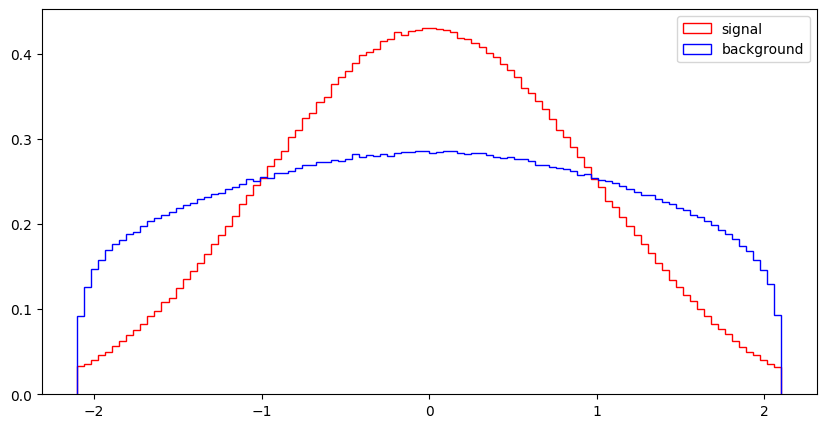

l_1_phi


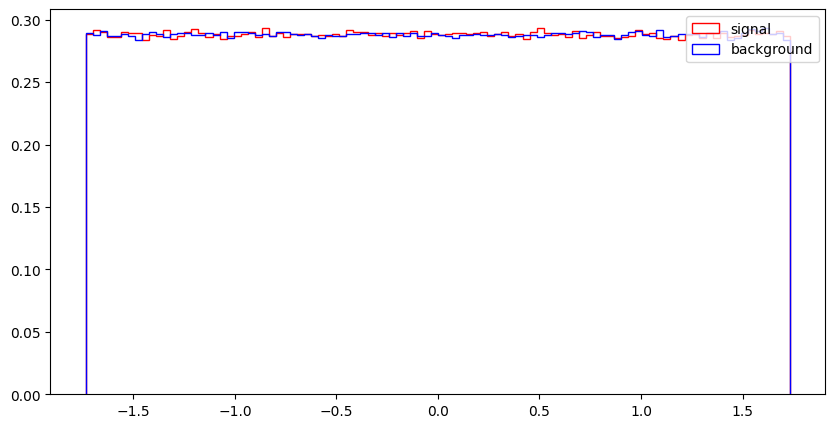

l_2_pT


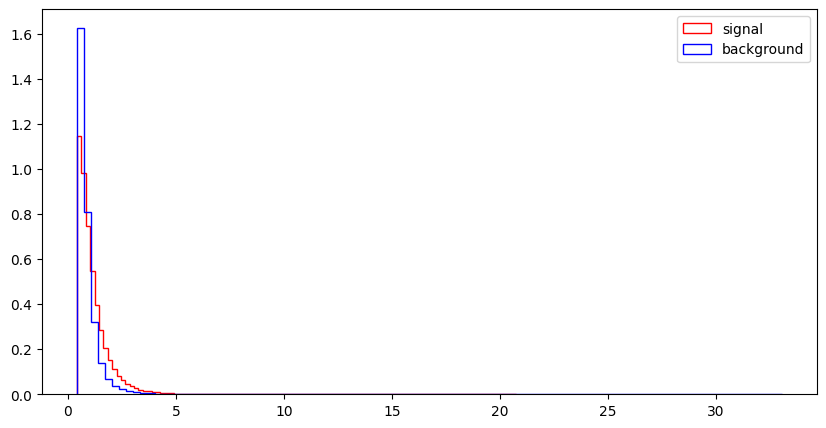

l_2_eta


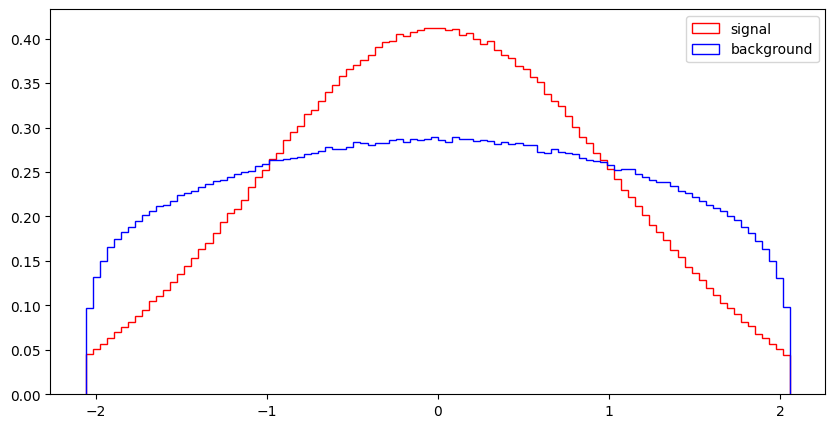

l_2_phi


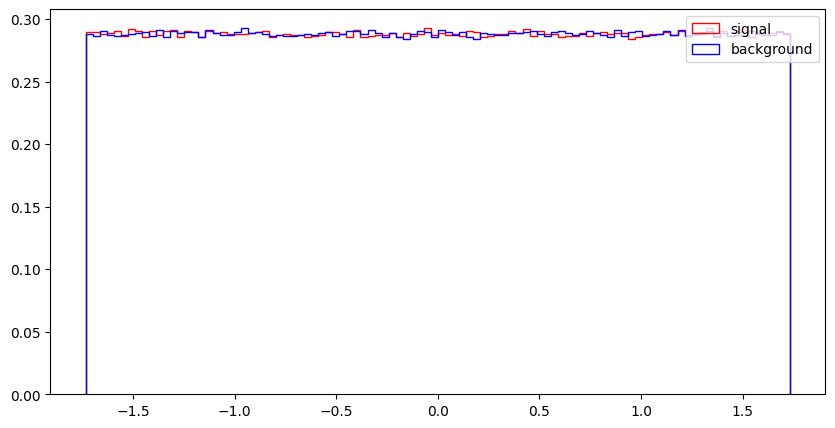

MET


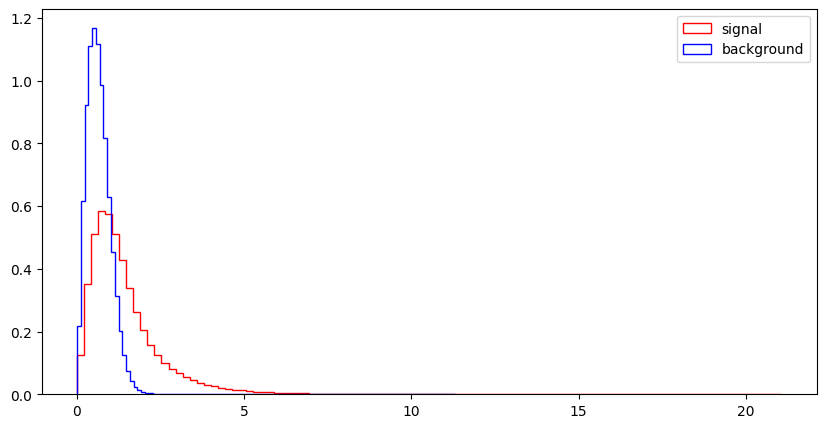

MET_phi


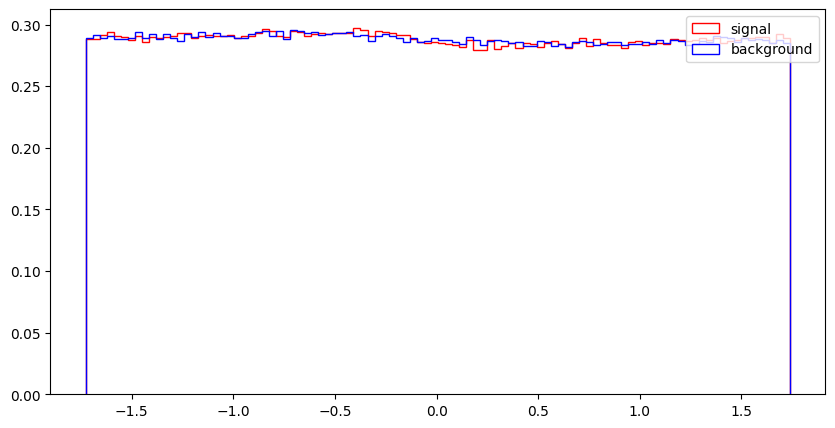

MET_rel


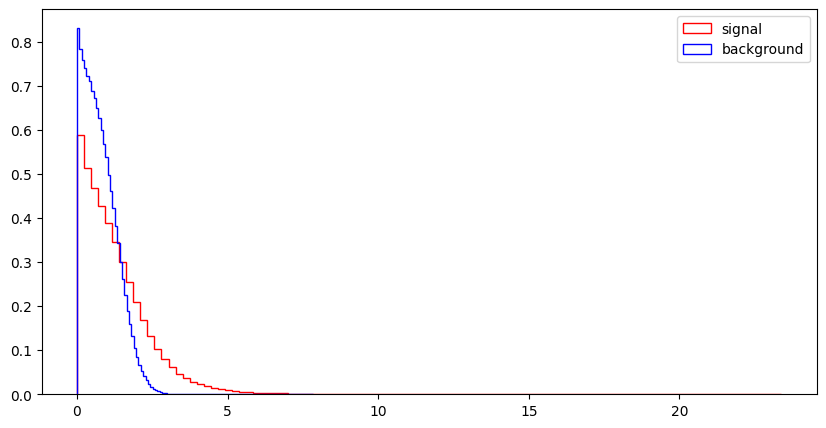

axial_MET


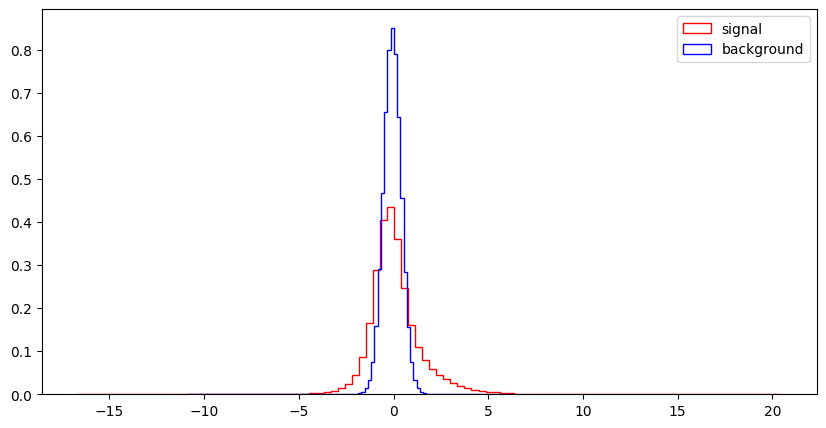

M_R


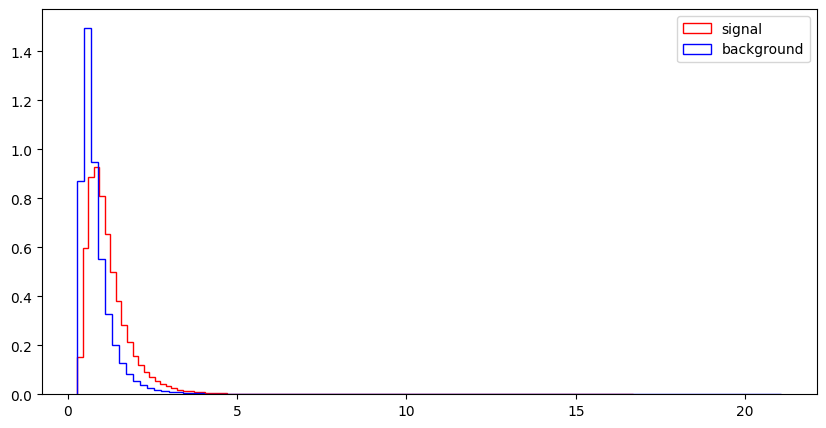

M_TR_2


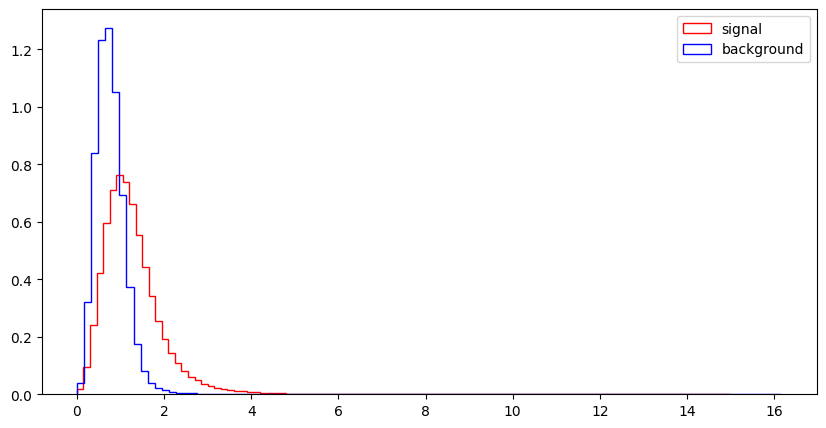

R


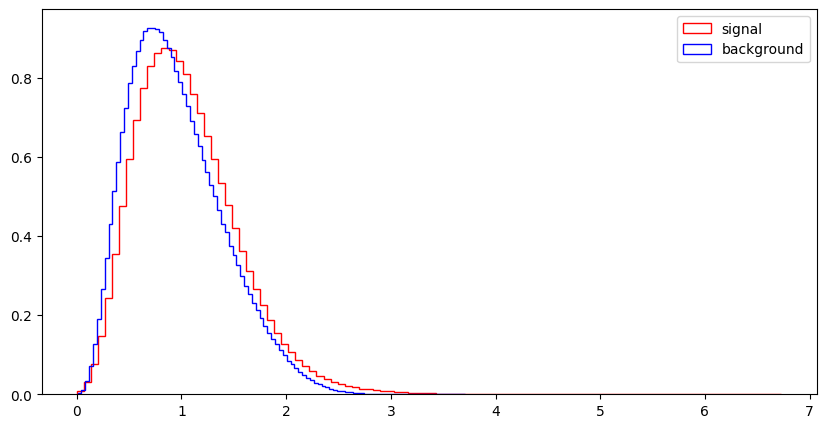

MT2


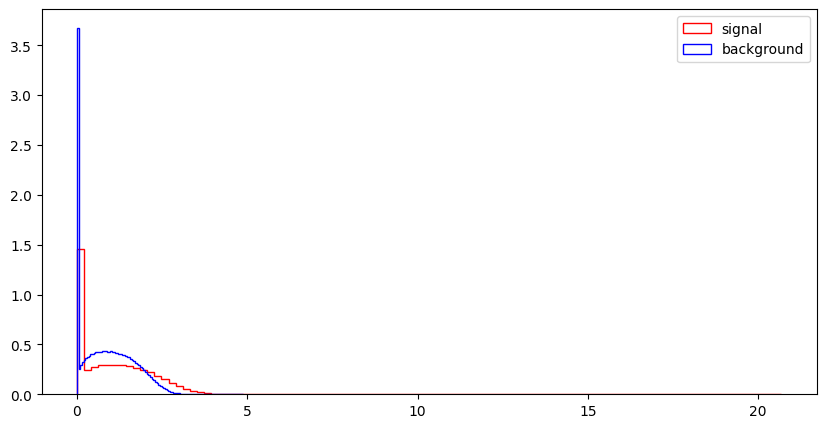

S_R


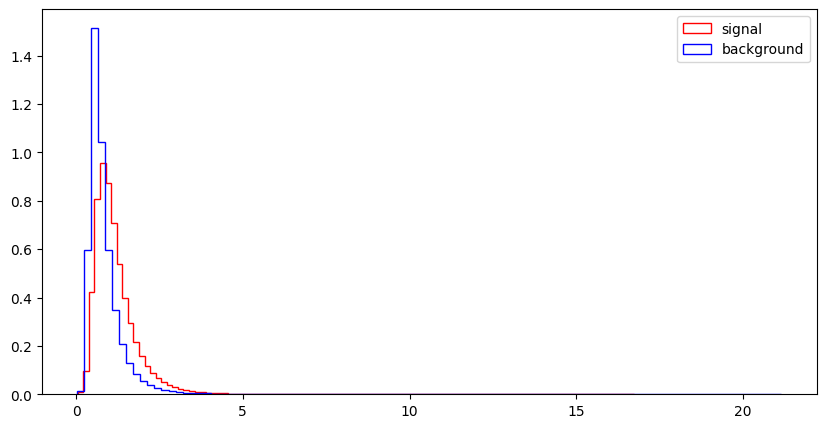

M_Delta_R


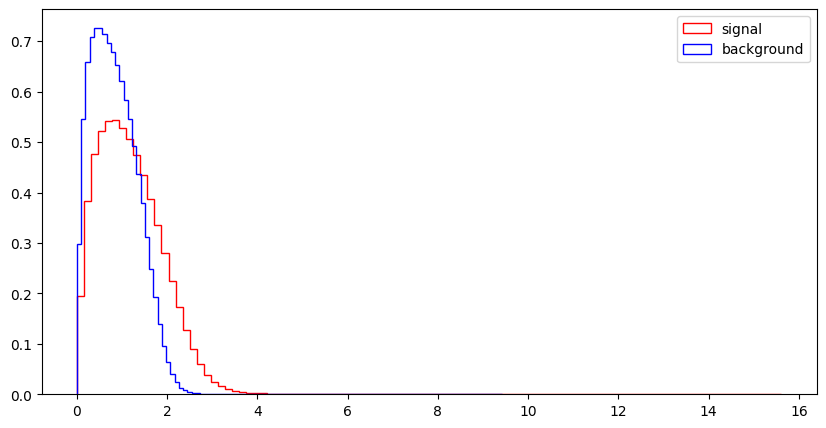

dPhi_r_b


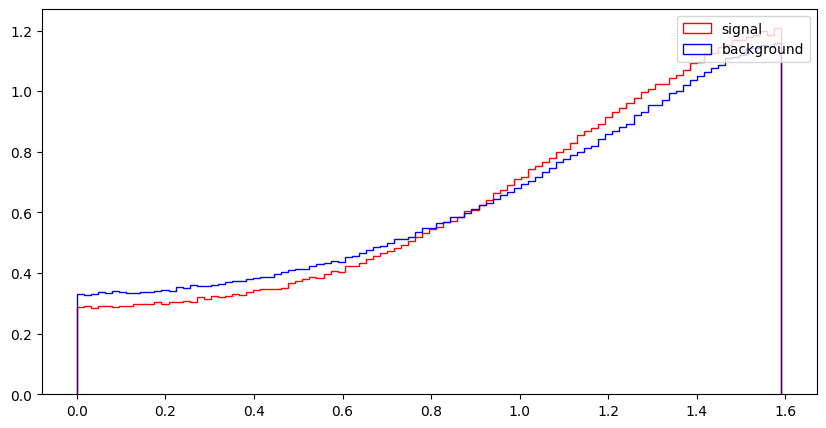

cos_theta_r1


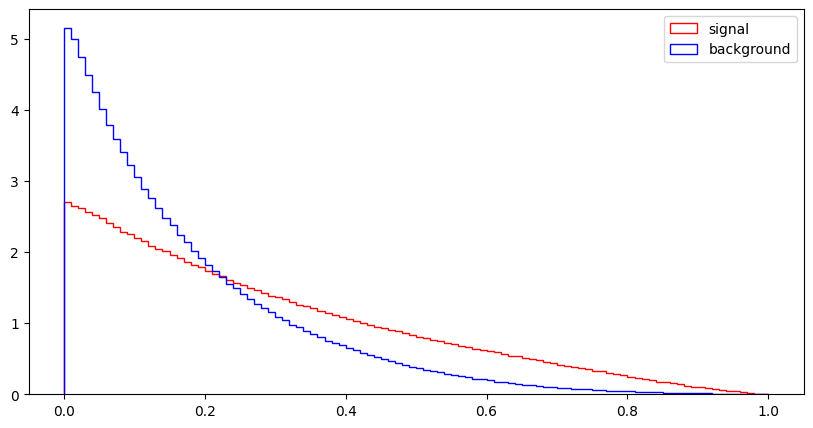

In [24]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

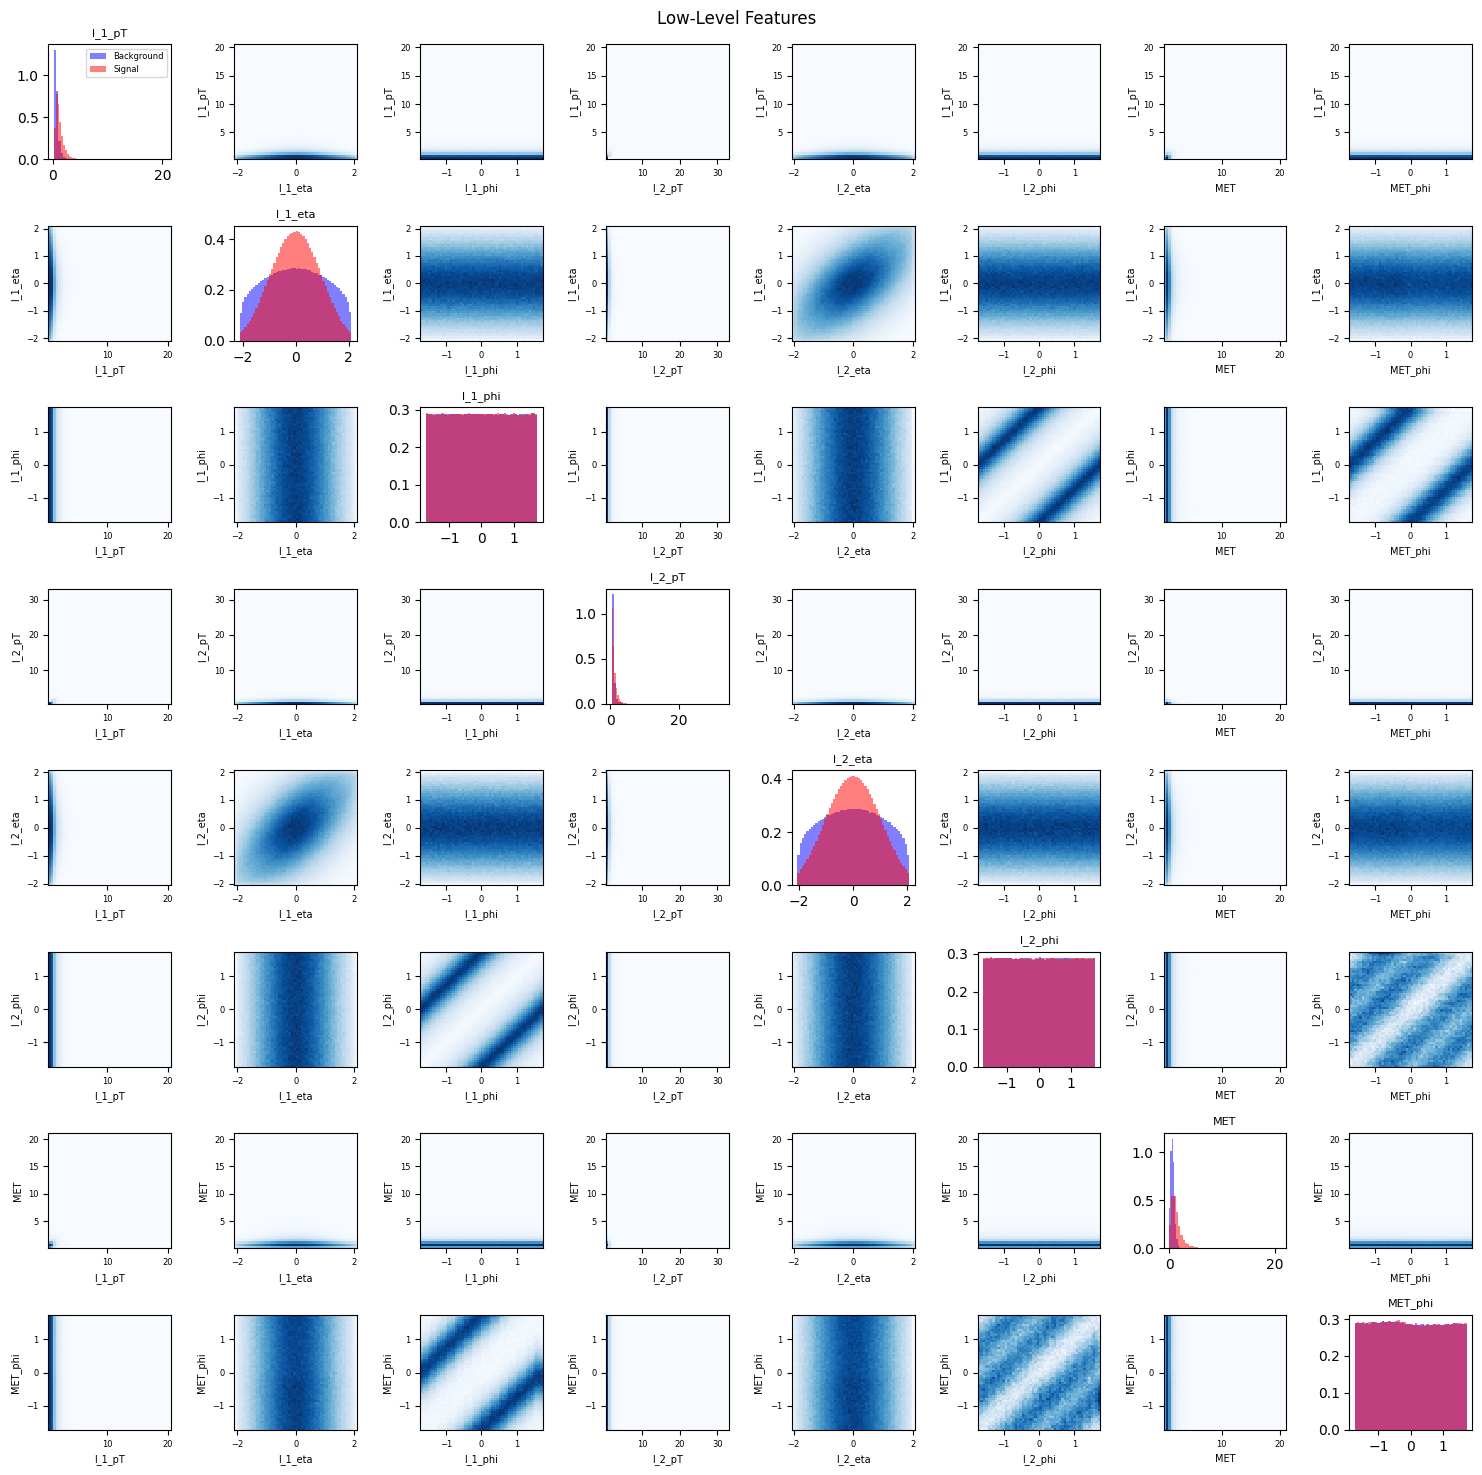

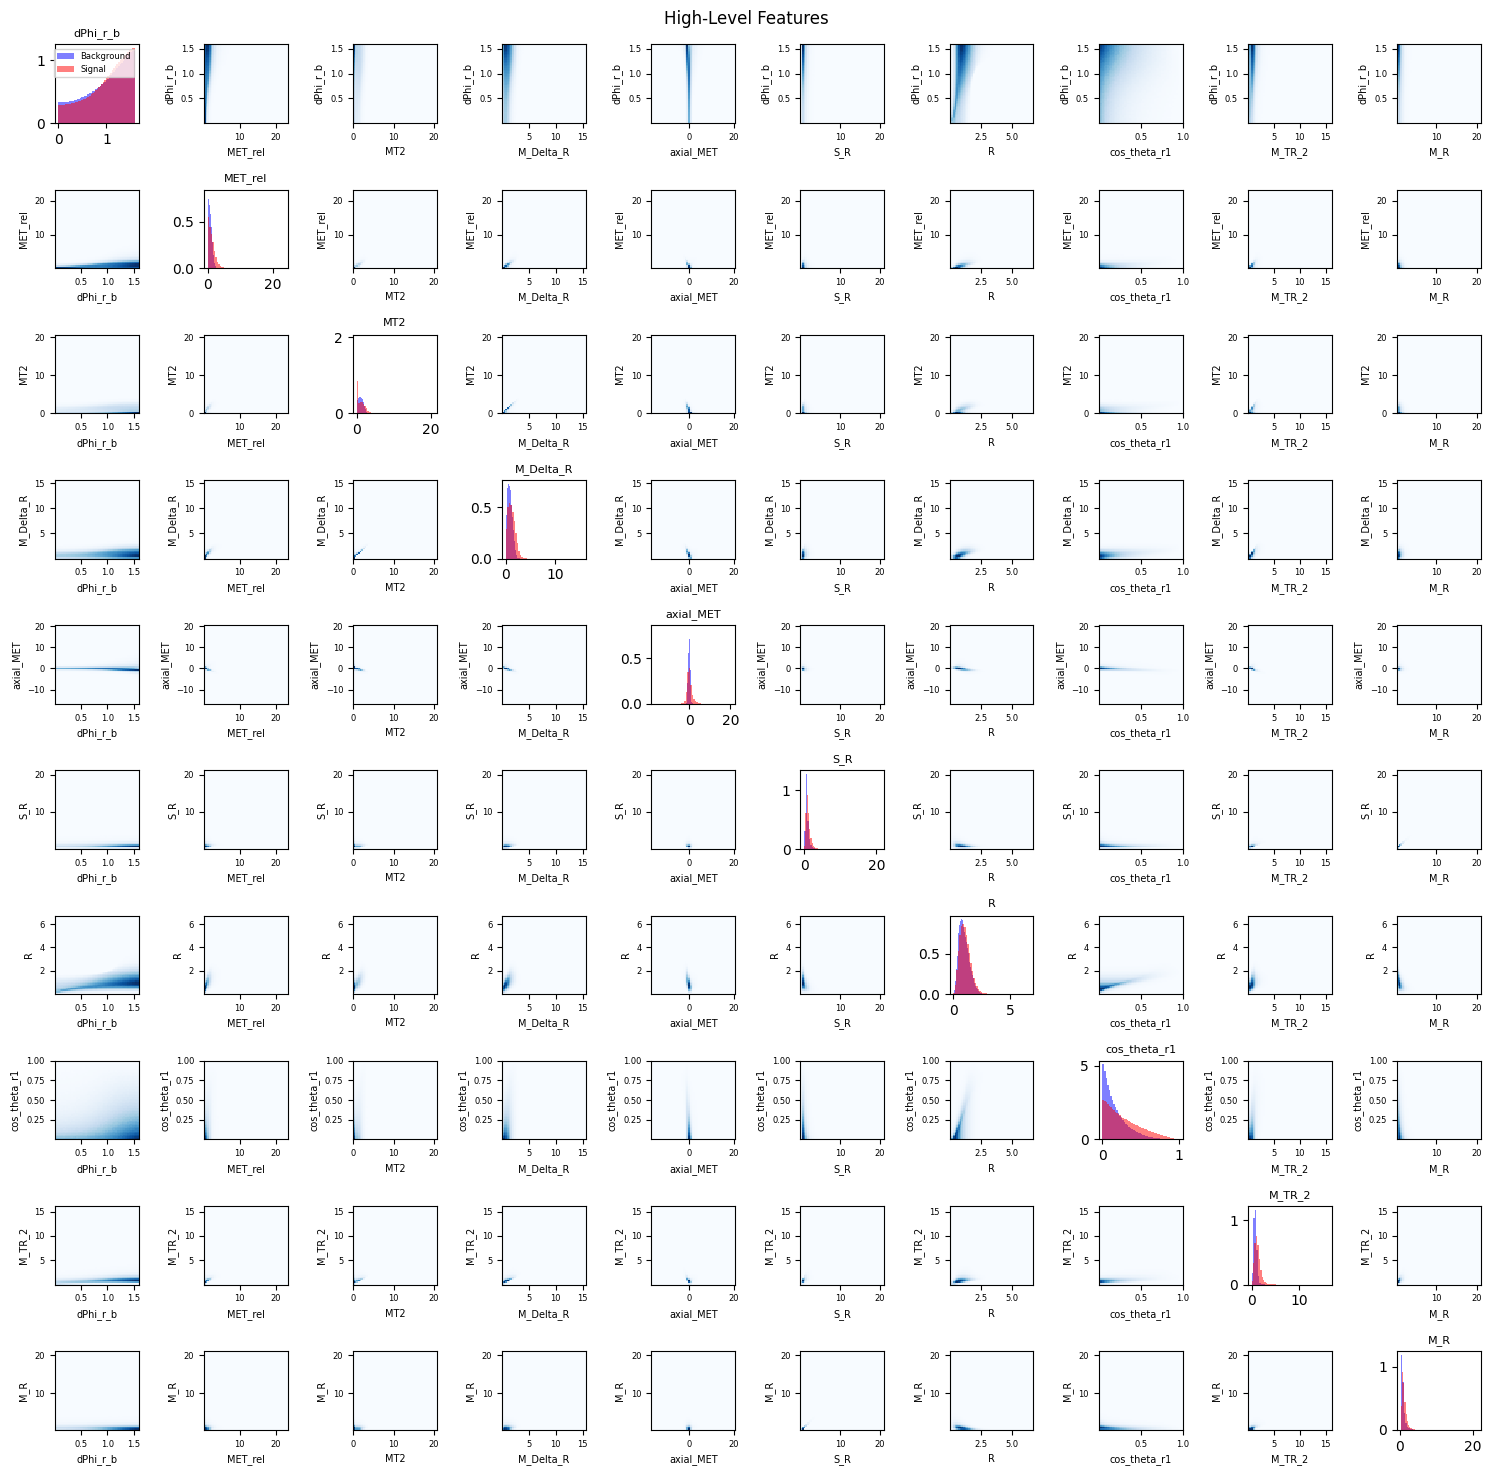

In [25]:
# Function that creates pair plots and compares variables in the SUSY sample
def pair_plot(df, vars, title):
    n = len(vars)
    signal = df[df["signal"] == 1]
    background = df[df["signal"] == 0]
    
    fig, axes = plt.subplots(n, n, figsize=(15, 15))
    
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                # Diagonal: overlapping signal vs background histograms
                ax.hist(background[vars[i]], bins=50, color='blue', alpha=0.5, density=True, label='Background')
                ax.hist(signal[vars[i]], bins=50, color='red', alpha=0.5, density=True, label='Signal')
                ax.set_title(vars[i], fontsize=8)
            else:
                # Off-diagonal: 2D histogram (much faster than scatter)
                ax.hist2d(df[vars[j]], df[vars[i]], bins=50, cmap='Blues')
                ax.set_xlabel(vars[j], fontsize=7)
                ax.set_ylabel(vars[i], fontsize=7)
                ax.tick_params(labelsize=6)
    
    # Add legend to first diagonal cell
    axes[0, 0].legend(fontsize=6)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# Call the function for your feature groups
pair_plot(df, RawNames, "Low-Level Features")
pair_plot(df, FeatureNames, "High-Level Features")

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?


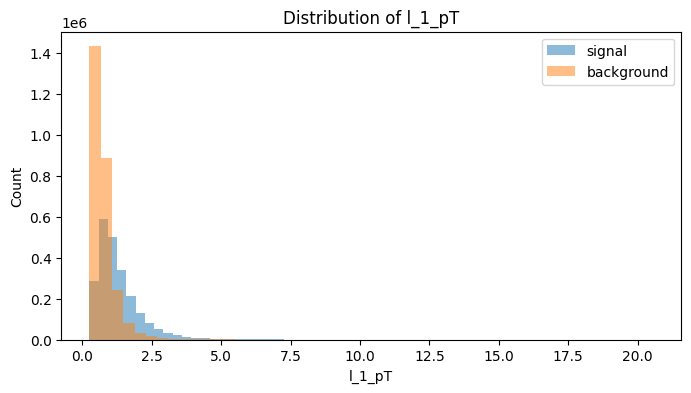

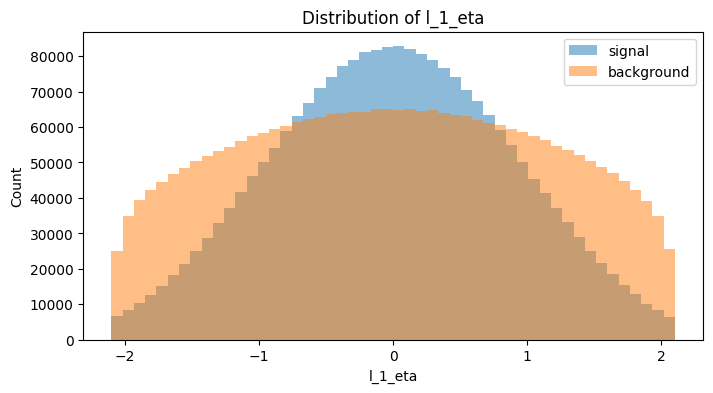

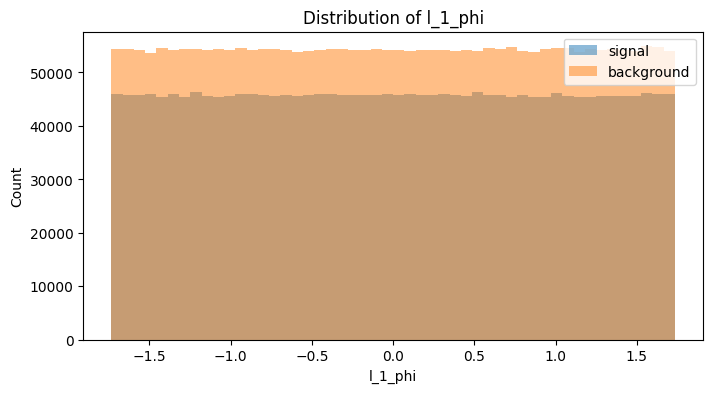

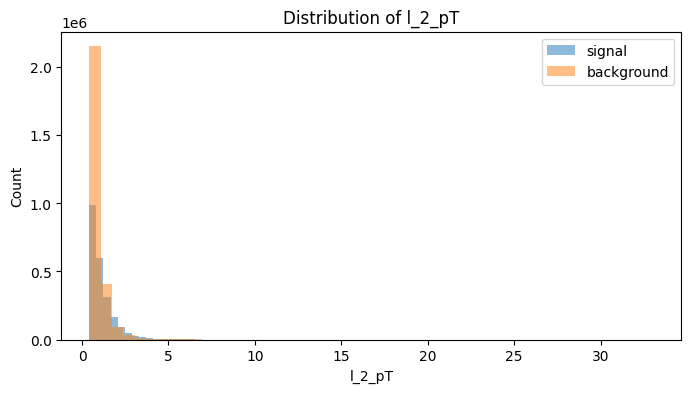

In [26]:
import numpy as np

for var in VarNames[1:5]:  # just do a few so it runs faster
    plt.figure(figsize=(8,4))
    
    plt.hist(df_sig[var], bins=50, alpha=0.5, label="signal")
    plt.hist(df_bkg[var], bins=50, alpha=0.5, label="background")
    
    plt.title("Distribution of " + var)
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.legend()
    
    plt.show()

#### Part c
Which observables appear to be best for separating signal from background?

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

In [27]:
import tabulate
from IPython.display import HTML, display

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

In [28]:
Cov_all=np.cov(df[VarNames[1:]].values.T)
Corr_all=np.corrcoef(df[VarNames[1:]].values.T)
Cov_raw=np.cov(df[RawNames].values.T)
Corr_raw=np.corrcoef(df[RawNames].values.T)
Cov_feat=np.cov(df[FeatureNames].values.T)
Corr_feat=np.corrcoef(df[FeatureNames].values.T)

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.
|

In [29]:
from IPython.display import display, HTML
import tabulate

# Covariance and correlation matrices
print("Covariance matrix between all observables")
display(HTML(tabulate.tabulate(
    Cov_all, 
    headers=VarNames[1:], 
    showindex=VarNames[1:], 
    floatfmt=".2e", 
    tablefmt="html"
)))

print("Correlation matrix between all observables")
display(HTML(tabulate.tabulate(
    Corr_all, 
    headers=VarNames[1:], 
    showindex=VarNames[1:], 
    floatfmt=".2e", 
    tablefmt="html"
)))

print("Covariance matrix between low-level features")
display(HTML(tabulate.tabulate(
    Cov_raw, 
    headers=RawNames, 
    showindex=RawNames, 
    floatfmt=".2e", 
    tablefmt="html"
)))

print("Correlation matrix between low-level features")
display(HTML(tabulate.tabulate(
    Corr_raw, 
    headers=RawNames, 
    showindex=RawNames, 
    floatfmt=".2e", 
    tablefmt="html"
)))

print("Covariance matrix between high-level features")
display(HTML(tabulate.tabulate(
    Cov_feat, 
    headers=FeatureNames, 
    showindex=FeatureNames, 
    floatfmt=".2e", 
    tablefmt="html"
)))

print("Correlation matrix between high-level features")
display(HTML(tabulate.tabulate(
    Corr_feat, 
    headers=FeatureNames, 
    showindex=FeatureNames, 
    floatfmt=".2e", 
    tablefmt="html"
)))

Covariance matrix between all observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,4.72e-01,-2.63e-04,-2.29e-04,3.08e-01,-3.02e-04,2.27e-04,2.31e-01,-6.76e-04,9.86e-02,-1.25e-02,3.68e-01,2.91e-01,-5.93e-02,-1.28e-02,3.46e-01,9.81e-02,-4.70e-02,2.25e-02
l_1_eta,-2.63e-04,1.01e+00,3.22e-04,-3.78e-04,4.06e-01,2.97e-04,-5.58e-04,-5.41e-04,-4.97e-04,-4.98e-04,-3.08e-04,-2.66e-04,1.28e-04,-1.58e-04,-2.81e-04,-5.04e-04,7.96e-05,1.46e-04
l_1_phi,-2.29e-04,3.22e-04,1.00e+00,-1.29e-04,6.41e-04,-2.68e-01,1.20e-03,-1.84e-01,1.53e-03,-1.96e-03,-2.00e-04,8.38e-04,8.76e-04,1.75e-03,4.50e-05,1.31e-03,9.54e-04,2.99e-04
l_2_pT,3.08e-01,-3.78e-04,-1.29e-04,4.28e-01,-4.54e-04,1.15e-04,7.97e-02,-1.39e-03,-2.26e-03,4.98e-02,3.28e-01,1.64e-01,-9.93e-02,-6.91e-02,3.25e-01,5.55e-03,-4.12e-03,-2.78e-02
l_2_eta,-3.02e-04,4.06e-01,6.41e-04,-4.54e-04,1.01e+00,-6.47e-05,5.12e-05,-1.26e-04,1.30e-04,-1.70e-04,-5.49e-04,-1.67e-04,2.53e-04,-9.06e-05,-5.54e-04,-2.15e-04,-5.16e-05,1.99e-04
l_2_phi,2.27e-04,2.97e-04,-2.68e-01,1.15e-04,-6.47e-05,1.00e+00,4.32e-06,-3.45e-02,2.14e-04,-9.14e-05,2.87e-04,2.88e-04,2.35e-04,1.24e-03,3.84e-04,4.96e-04,2.44e-04,-1.99e-04
MET,2.31e-01,-5.58e-04,1.20e-03,7.97e-02,5.12e-05,4.32e-06,7.62e-01,-1.62e-03,5.48e-01,1.45e-01,1.46e-01,3.68e-01,1.89e-01,1.56e-01,1.67e-01,3.17e-01,1.45e-01,7.33e-02
MET_phi,-6.76e-04,-5.41e-04,-1.84e-01,-1.39e-03,-1.26e-04,-3.45e-02,-1.62e-03,1.00e+00,-2.92e-03,-9.53e-04,-9.76e-04,-8.42e-04,-1.63e-04,5.05e-04,-1.14e-03,-3.99e-04,-1.32e-03,5.78e-05
MET_rel,9.86e-02,-4.97e-04,1.53e-03,-2.26e-03,1.30e-04,2.14e-04,5.48e-01,-2.92e-03,7.92e-01,-1.25e-01,4.37e-02,3.03e-01,2.50e-01,4.10e-01,8.24e-02,4.16e-01,1.47e-01,5.56e-02
axial_MET,-1.25e-02,-4.98e-04,-1.96e-03,4.98e-02,-1.70e-04,-9.14e-05,1.45e-01,-9.53e-04,-1.25e-01,1.00e+00,1.51e-02,-1.89e-01,-1.82e-01,-4.60e-01,-4.34e-02,-2.34e-01,-2.62e-02,-5.41e-02


Correlation matrix between all observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1.00e+00,-3.81e-04,-3.33e-04,6.85e-01,-4.39e-04,3.30e-04,3.85e-01,-9.82e-04,1.61e-01,-1.82e-02,8.52e-01,7.24e-01,-1.83e-01,-2.16e-02,8.12e-01,2.29e-01,-1.57e-01,1.66e-01
l_1_eta,-3.81e-04,1.00e+00,3.20e-04,-5.76e-04,4.03e-01,2.96e-04,-6.37e-04,-5.38e-04,-5.56e-04,-4.95e-04,-4.88e-04,-4.54e-04,2.70e-04,-1.83e-04,-4.52e-04,-8.06e-04,1.82e-04,7.38e-04
l_1_phi,-3.33e-04,3.20e-04,1.00e+00,-1.96e-04,6.38e-04,-2.67e-01,1.37e-03,-1.84e-01,1.71e-03,-1.96e-03,-3.17e-04,1.43e-03,1.86e-03,2.04e-03,7.23e-05,2.10e-03,2.18e-03,1.52e-03
l_2_pT,6.85e-01,-5.76e-04,-1.96e-04,1.00e+00,-6.92e-04,1.75e-04,1.40e-01,-2.12e-03,-3.88e-03,7.60e-02,7.98e-01,4.30e-01,-3.22e-01,-1.23e-01,7.99e-01,1.36e-02,-1.44e-02,-2.16e-01
l_2_eta,-4.39e-04,4.03e-01,6.38e-04,-6.92e-04,1.00e+00,-6.44e-05,5.85e-05,-1.25e-04,1.45e-04,-1.69e-04,-8.70e-04,-2.85e-04,5.37e-04,-1.05e-04,-8.89e-04,-3.43e-04,-1.18e-04,1.01e-03
l_2_phi,3.30e-04,2.96e-04,-2.67e-01,1.75e-04,-6.44e-05,1.00e+00,4.94e-06,-3.44e-02,2.40e-04,-9.11e-05,4.55e-04,4.92e-04,4.98e-04,1.44e-03,6.17e-04,7.94e-04,5.58e-04,-1.01e-03
MET,3.85e-01,-6.37e-04,1.37e-03,1.40e-01,5.85e-05,4.94e-06,1.00e+00,-1.85e-03,7.06e-01,1.66e-01,2.66e-01,7.22e-01,4.59e-01,2.09e-01,3.09e-01,5.81e-01,3.82e-01,4.26e-01
MET_phi,-9.82e-04,-5.38e-04,-1.84e-01,-2.12e-03,-1.25e-04,-3.44e-02,-1.85e-03,1.00e+00,-3.27e-03,-9.50e-04,-1.55e-03,-1.44e-03,-3.46e-04,5.87e-04,-1.83e-03,-6.38e-04,-3.03e-03,2.93e-04
MET_rel,1.61e-01,-5.56e-04,1.71e-03,-3.88e-03,1.45e-04,2.40e-04,7.06e-01,-3.27e-03,1.00e+00,-1.41e-01,7.81e-02,5.83e-01,5.95e-01,5.36e-01,1.49e-01,7.49e-01,3.78e-01,3.17e-01
axial_MET,-1.82e-02,-4.95e-04,-1.96e-03,7.60e-02,-1.69e-04,-9.11e-05,1.66e-01,-9.50e-04,-1.41e-01,1.00e+00,2.40e-02,-3.23e-01,-3.85e-01,-5.35e-01,-6.98e-02,-3.75e-01,-6.00e-02,-2.74e-01


Covariance matrix between low-level features


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1.00e+00,-3.81e-04,-3.33e-04,6.85e-01,-4.39e-04,3.30e-04,3.85e-01,-9.82e-04
l_1_eta,-3.81e-04,1.00e+00,3.20e-04,-5.76e-04,4.03e-01,2.96e-04,-6.37e-04,-5.38e-04
l_1_phi,-3.33e-04,3.20e-04,1.00e+00,-1.96e-04,6.38e-04,-2.67e-01,1.37e-03,-1.84e-01
l_2_pT,6.85e-01,-5.76e-04,-1.96e-04,1.00e+00,-6.92e-04,1.75e-04,1.40e-01,-2.12e-03
l_2_eta,-4.39e-04,4.03e-01,6.38e-04,-6.92e-04,1.00e+00,-6.44e-05,5.85e-05,-1.25e-04
l_2_phi,3.30e-04,2.96e-04,-2.67e-01,1.75e-04,-6.44e-05,1.00e+00,4.94e-06,-3.44e-02
MET,3.85e-01,-6.37e-04,1.37e-03,1.40e-01,5.85e-05,4.94e-06,1.00e+00,-1.85e-03
MET_phi,-9.82e-04,-5.38e-04,-1.84e-01,-2.12e-03,-1.25e-04,-3.44e-02,-1.85e-03,1.00e+00


Covariance matrix between high-level features


,dPhi_r_b,MET_rel,MT2,M_Delta_R,axial_MET,S_R,R,cos_theta_r1,M_TR_2,M_R
dPhi_r_b,1.90e-01,1.47e-01,2.12e-02,4.24e-02,-2.62e-02,-3.63e-03,8.71e-02,9.13e-03,5.81e-02,-2.91e-02
MET_rel,1.47e-01,7.92e-01,4.10e-01,4.16e-01,-1.25e-01,8.24e-02,2.50e-01,5.56e-02,3.03e-01,4.37e-02
MT2,2.12e-02,4.10e-01,7.38e-01,4.33e-01,-4.60e-01,-1.12e-02,2.32e-01,4.45e-02,1.89e-01,-3.66e-02
M_Delta_R,4.24e-02,4.16e-01,4.33e-01,3.89e-01,-2.34e-01,9.61e-02,1.66e-01,3.92e-02,2.42e-01,7.43e-02
axial_MET,-2.62e-02,-1.25e-01,-4.60e-01,-2.34e-01,1.00e+00,-4.34e-02,-1.82e-01,-5.41e-02,-1.89e-01,1.51e-02
S_R,-3.63e-03,8.24e-02,-1.12e-02,9.61e-02,-4.34e-02,3.85e-01,-8.34e-02,-1.02e-02,2.30e-01,3.83e-01
R,8.71e-02,2.50e-01,2.32e-01,1.66e-01,-1.82e-01,-8.34e-02,2.22e-01,5.82e-02,1.04e-01,-1.13e-01
cos_theta_r1,9.13e-03,5.56e-02,4.45e-02,3.92e-02,-5.41e-02,-1.02e-02,5.82e-02,3.88e-02,5.19e-02,-1.42e-02
M_TR_2,5.81e-02,3.03e-01,1.89e-01,2.42e-01,-1.89e-01,2.30e-01,1.04e-01,5.19e-02,3.41e-01,2.12e-01
M_R,-2.91e-02,4.37e-02,-3.66e-02,7.43e-02,1.51e-02,3.83e-01,-1.13e-01,-1.42e-02,2.12e-01,3.95e-01


Correlation matrix between high-level features


,dPhi_r_b,MET_rel,MT2,M_Delta_R,axial_MET,S_R,R,cos_theta_r1,M_TR_2,M_R
dPhi_r_b,1.00e+00,3.78e-01,5.65e-02,1.56e-01,-6.00e-02,-1.34e-02,4.24e-01,1.06e-01,2.28e-01,-1.06e-01
MET_rel,3.78e-01,1.00e+00,5.36e-01,7.49e-01,-1.41e-01,1.49e-01,5.95e-01,3.17e-01,5.83e-01,7.81e-02
MT2,5.65e-02,5.36e-01,1.00e+00,8.08e-01,-5.35e-01,-2.09e-02,5.74e-01,2.63e-01,3.78e-01,-6.78e-02
M_Delta_R,1.56e-01,7.49e-01,8.08e-01,1.00e+00,-3.75e-01,2.48e-01,5.64e-01,3.19e-01,6.66e-01,1.89e-01
axial_MET,-6.00e-02,-1.41e-01,-5.35e-01,-3.75e-01,1.00e+00,-6.98e-02,-3.85e-01,-2.74e-01,-3.23e-01,2.40e-02
S_R,-1.34e-02,1.49e-01,-2.09e-02,2.48e-01,-6.98e-02,1.00e+00,-2.85e-01,-8.36e-02,6.36e-01,9.81e-01
R,4.24e-01,5.95e-01,5.74e-01,5.64e-01,-3.85e-01,-2.85e-01,1.00e+00,6.27e-01,3.80e-01,-3.81e-01
cos_theta_r1,1.06e-01,3.17e-01,2.63e-01,3.19e-01,-2.74e-01,-8.36e-02,6.27e-01,1.00e+00,4.51e-01,-1.15e-01
M_TR_2,2.28e-01,5.83e-01,3.78e-01,6.66e-01,-3.23e-01,6.36e-01,3.80e-01,4.51e-01,1.00e+00,5.78e-01
M_R,-1.06e-01,7.81e-02,-6.78e-02,1.89e-01,2.40e-02,9.81e-01,-3.81e-01,-1.15e-01,5.78e-01,1.00e+00


#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [30]:
from IPython.display import display, HTML
import tabulate
import pandas as pd

def analyze_features(df, feature_groups, feature_names_dict):
    """
    Perform covariance and correlation analysis on the given dataset.

    Parameters:
    df                 : pandas DataFrame containing the dataset (must include 'signal' column)
    feature_groups     : list of feature groups to analyze, e.g., ['all', 'low', 'high']
    feature_names_dict : dictionary mapping group names to column names, e.g.,
                         {
                            'all': VarNames[1:],
                            'low': RawNames,
                            'high': FeatureNames
                         }

    Steps performed:
    - Compute covariance and correlation matrices
    - Display them in HTML tables using tabulate
    """
    for group in feature_groups:
        cols = feature_names_dict[group]
        data = df[cols]

        Cov = data.cov()
        Corr = data.corr()

        print(f"Covariance matrix for {group}-level features")
        display(HTML(tabulate.tabulate(Cov, headers=cols, showindex=cols, floatfmt=".2e", tablefmt="html")))

        print(f"Correlation matrix for {group}-level features")
        display(HTML(tabulate.tabulate(Corr, headers=cols, showindex=cols, floatfmt=".2e", tablefmt="html")))

# -----------------------------
# Example usage
# -----------------------------
feature_names_dict = {
    'all': VarNames[1:],      # all observables
    'low': RawNames,          # low-level features
    'high': FeatureNames      # high-level features
}

analyze_features(df, ['all', 'low', 'high'], feature_names_dict)

Covariance matrix for all-level features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,4.72e-01,-2.63e-04,-2.29e-04,3.08e-01,-3.02e-04,2.27e-04,2.31e-01,-6.76e-04,9.86e-02,-1.25e-02,3.68e-01,2.91e-01,-5.93e-02,-1.28e-02,3.46e-01,9.81e-02,-4.70e-02,2.25e-02
l_1_eta,-2.63e-04,1.01e+00,3.22e-04,-3.78e-04,4.06e-01,2.97e-04,-5.58e-04,-5.41e-04,-4.97e-04,-4.98e-04,-3.08e-04,-2.66e-04,1.28e-04,-1.58e-04,-2.81e-04,-5.04e-04,7.96e-05,1.46e-04
l_1_phi,-2.29e-04,3.22e-04,1.00e+00,-1.29e-04,6.41e-04,-2.68e-01,1.20e-03,-1.84e-01,1.53e-03,-1.96e-03,-2.00e-04,8.38e-04,8.76e-04,1.75e-03,4.50e-05,1.31e-03,9.54e-04,2.99e-04
l_2_pT,3.08e-01,-3.78e-04,-1.29e-04,4.28e-01,-4.54e-04,1.15e-04,7.97e-02,-1.39e-03,-2.26e-03,4.98e-02,3.28e-01,1.64e-01,-9.93e-02,-6.91e-02,3.25e-01,5.55e-03,-4.12e-03,-2.78e-02
l_2_eta,-3.02e-04,4.06e-01,6.41e-04,-4.54e-04,1.01e+00,-6.47e-05,5.12e-05,-1.26e-04,1.30e-04,-1.70e-04,-5.49e-04,-1.67e-04,2.53e-04,-9.06e-05,-5.54e-04,-2.15e-04,-5.16e-05,1.99e-04
l_2_phi,2.27e-04,2.97e-04,-2.68e-01,1.15e-04,-6.47e-05,1.00e+00,4.32e-06,-3.45e-02,2.14e-04,-9.14e-05,2.87e-04,2.88e-04,2.35e-04,1.24e-03,3.84e-04,4.96e-04,2.44e-04,-1.99e-04
MET,2.31e-01,-5.58e-04,1.20e-03,7.97e-02,5.12e-05,4.32e-06,7.62e-01,-1.62e-03,5.48e-01,1.45e-01,1.46e-01,3.68e-01,1.89e-01,1.56e-01,1.67e-01,3.17e-01,1.45e-01,7.33e-02
MET_phi,-6.76e-04,-5.41e-04,-1.84e-01,-1.39e-03,-1.26e-04,-3.45e-02,-1.62e-03,1.00e+00,-2.92e-03,-9.53e-04,-9.76e-04,-8.42e-04,-1.63e-04,5.05e-04,-1.14e-03,-3.99e-04,-1.32e-03,5.78e-05
MET_rel,9.86e-02,-4.97e-04,1.53e-03,-2.26e-03,1.30e-04,2.14e-04,5.48e-01,-2.92e-03,7.92e-01,-1.25e-01,4.37e-02,3.03e-01,2.50e-01,4.10e-01,8.24e-02,4.16e-01,1.47e-01,5.56e-02
axial_MET,-1.25e-02,-4.98e-04,-1.96e-03,4.98e-02,-1.70e-04,-9.14e-05,1.45e-01,-9.53e-04,-1.25e-01,1.00e+00,1.51e-02,-1.89e-01,-1.82e-01,-4.60e-01,-4.34e-02,-2.34e-01,-2.62e-02,-5.41e-02


Correlation matrix for all-level features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1.00e+00,-3.81e-04,-3.33e-04,6.85e-01,-4.39e-04,3.30e-04,3.85e-01,-9.82e-04,1.61e-01,-1.82e-02,8.52e-01,7.24e-01,-1.83e-01,-2.16e-02,8.12e-01,2.29e-01,-1.57e-01,1.66e-01
l_1_eta,-3.81e-04,1.00e+00,3.20e-04,-5.76e-04,4.03e-01,2.96e-04,-6.37e-04,-5.38e-04,-5.56e-04,-4.95e-04,-4.88e-04,-4.54e-04,2.70e-04,-1.83e-04,-4.52e-04,-8.06e-04,1.82e-04,7.38e-04
l_1_phi,-3.33e-04,3.20e-04,1.00e+00,-1.96e-04,6.38e-04,-2.67e-01,1.37e-03,-1.84e-01,1.71e-03,-1.96e-03,-3.17e-04,1.43e-03,1.86e-03,2.04e-03,7.23e-05,2.10e-03,2.18e-03,1.52e-03
l_2_pT,6.85e-01,-5.76e-04,-1.96e-04,1.00e+00,-6.92e-04,1.75e-04,1.40e-01,-2.12e-03,-3.88e-03,7.60e-02,7.98e-01,4.30e-01,-3.22e-01,-1.23e-01,7.99e-01,1.36e-02,-1.44e-02,-2.16e-01
l_2_eta,-4.39e-04,4.03e-01,6.38e-04,-6.92e-04,1.00e+00,-6.44e-05,5.85e-05,-1.25e-04,1.45e-04,-1.69e-04,-8.70e-04,-2.85e-04,5.37e-04,-1.05e-04,-8.89e-04,-3.43e-04,-1.18e-04,1.01e-03
l_2_phi,3.30e-04,2.96e-04,-2.67e-01,1.75e-04,-6.44e-05,1.00e+00,4.94e-06,-3.44e-02,2.40e-04,-9.11e-05,4.55e-04,4.92e-04,4.98e-04,1.44e-03,6.17e-04,7.94e-04,5.58e-04,-1.01e-03
MET,3.85e-01,-6.37e-04,1.37e-03,1.40e-01,5.85e-05,4.94e-06,1.00e+00,-1.85e-03,7.06e-01,1.66e-01,2.66e-01,7.22e-01,4.59e-01,2.09e-01,3.09e-01,5.81e-01,3.82e-01,4.26e-01
MET_phi,-9.82e-04,-5.38e-04,-1.84e-01,-2.12e-03,-1.25e-04,-3.44e-02,-1.85e-03,1.00e+00,-3.27e-03,-9.50e-04,-1.55e-03,-1.44e-03,-3.46e-04,5.87e-04,-1.83e-03,-6.38e-04,-3.03e-03,2.93e-04
MET_rel,1.61e-01,-5.56e-04,1.71e-03,-3.88e-03,1.45e-04,2.40e-04,7.06e-01,-3.27e-03,1.00e+00,-1.41e-01,7.81e-02,5.83e-01,5.95e-01,5.36e-01,1.49e-01,7.49e-01,3.78e-01,3.17e-01
axial_MET,-1.82e-02,-4.95e-04,-1.96e-03,7.60e-02,-1.69e-04,-9.11e-05,1.66e-01,-9.50e-04,-1.41e-01,1.00e+00,2.40e-02,-3.23e-01,-3.85e-01,-5.35e-01,-6.98e-02,-3.75e-01,-6.00e-02,-2.74e-01


Covariance matrix for low-level features


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1.00e+00,-3.81e-04,-3.33e-04,6.85e-01,-4.39e-04,3.30e-04,3.85e-01,-9.82e-04
l_1_eta,-3.81e-04,1.00e+00,3.20e-04,-5.76e-04,4.03e-01,2.96e-04,-6.37e-04,-5.38e-04
l_1_phi,-3.33e-04,3.20e-04,1.00e+00,-1.96e-04,6.38e-04,-2.67e-01,1.37e-03,-1.84e-01
l_2_pT,6.85e-01,-5.76e-04,-1.96e-04,1.00e+00,-6.92e-04,1.75e-04,1.40e-01,-2.12e-03
l_2_eta,-4.39e-04,4.03e-01,6.38e-04,-6.92e-04,1.00e+00,-6.44e-05,5.85e-05,-1.25e-04
l_2_phi,3.30e-04,2.96e-04,-2.67e-01,1.75e-04,-6.44e-05,1.00e+00,4.94e-06,-3.44e-02
MET,3.85e-01,-6.37e-04,1.37e-03,1.40e-01,5.85e-05,4.94e-06,1.00e+00,-1.85e-03
MET_phi,-9.82e-04,-5.38e-04,-1.84e-01,-2.12e-03,-1.25e-04,-3.44e-02,-1.85e-03,1.00e+00


Covariance matrix for high-level features


,dPhi_r_b,MET_rel,MT2,M_Delta_R,axial_MET,S_R,R,cos_theta_r1,M_TR_2,M_R
dPhi_r_b,1.90e-01,1.47e-01,2.12e-02,4.24e-02,-2.62e-02,-3.63e-03,8.71e-02,9.13e-03,5.81e-02,-2.91e-02
MET_rel,1.47e-01,7.92e-01,4.10e-01,4.16e-01,-1.25e-01,8.24e-02,2.50e-01,5.56e-02,3.03e-01,4.37e-02
MT2,2.12e-02,4.10e-01,7.38e-01,4.33e-01,-4.60e-01,-1.12e-02,2.32e-01,4.45e-02,1.89e-01,-3.66e-02
M_Delta_R,4.24e-02,4.16e-01,4.33e-01,3.89e-01,-2.34e-01,9.61e-02,1.66e-01,3.92e-02,2.42e-01,7.43e-02
axial_MET,-2.62e-02,-1.25e-01,-4.60e-01,-2.34e-01,1.00e+00,-4.34e-02,-1.82e-01,-5.41e-02,-1.89e-01,1.51e-02
S_R,-3.63e-03,8.24e-02,-1.12e-02,9.61e-02,-4.34e-02,3.85e-01,-8.34e-02,-1.02e-02,2.30e-01,3.83e-01
R,8.71e-02,2.50e-01,2.32e-01,1.66e-01,-1.82e-01,-8.34e-02,2.22e-01,5.82e-02,1.04e-01,-1.13e-01
cos_theta_r1,9.13e-03,5.56e-02,4.45e-02,3.92e-02,-5.41e-02,-1.02e-02,5.82e-02,3.88e-02,5.19e-02,-1.42e-02
M_TR_2,5.81e-02,3.03e-01,1.89e-01,2.42e-01,-1.89e-01,2.30e-01,1.04e-01,5.19e-02,3.41e-01,2.12e-01
M_R,-2.91e-02,4.37e-02,-3.66e-02,7.43e-02,1.51e-02,3.83e-01,-1.13e-01,-1.42e-02,2.12e-01,3.95e-01


Correlation matrix for high-level features


,dPhi_r_b,MET_rel,MT2,M_Delta_R,axial_MET,S_R,R,cos_theta_r1,M_TR_2,M_R
dPhi_r_b,1.00e+00,3.78e-01,5.65e-02,1.56e-01,-6.00e-02,-1.34e-02,4.24e-01,1.06e-01,2.28e-01,-1.06e-01
MET_rel,3.78e-01,1.00e+00,5.36e-01,7.49e-01,-1.41e-01,1.49e-01,5.95e-01,3.17e-01,5.83e-01,7.81e-02
MT2,5.65e-02,5.36e-01,1.00e+00,8.08e-01,-5.35e-01,-2.09e-02,5.74e-01,2.63e-01,3.78e-01,-6.78e-02
M_Delta_R,1.56e-01,7.49e-01,8.08e-01,1.00e+00,-3.75e-01,2.48e-01,5.64e-01,3.19e-01,6.66e-01,1.89e-01
axial_MET,-6.00e-02,-1.41e-01,-5.35e-01,-3.75e-01,1.00e+00,-6.98e-02,-3.85e-01,-2.74e-01,-3.23e-01,2.40e-02
S_R,-1.34e-02,1.49e-01,-2.09e-02,2.48e-01,-6.98e-02,1.00e+00,-2.85e-01,-8.36e-02,6.36e-01,9.81e-01
R,4.24e-01,5.95e-01,5.74e-01,5.64e-01,-3.85e-01,-2.85e-01,1.00e+00,6.27e-01,3.80e-01,-3.81e-01
cos_theta_r1,1.06e-01,3.17e-01,2.63e-01,3.19e-01,-2.74e-01,-8.36e-02,6.27e-01,1.00e+00,4.51e-01,-1.15e-01
M_TR_2,2.28e-01,5.83e-01,3.78e-01,6.66e-01,-3.23e-01,6.36e-01,3.80e-01,4.51e-01,1.00e+00,5.78e-01
M_R,-1.06e-01,7.81e-02,-6.78e-02,1.89e-01,2.40e-02,9.81e-01,-3.81e-01,-1.15e-01,5.78e-01,1.00e+00


In [31]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.


### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

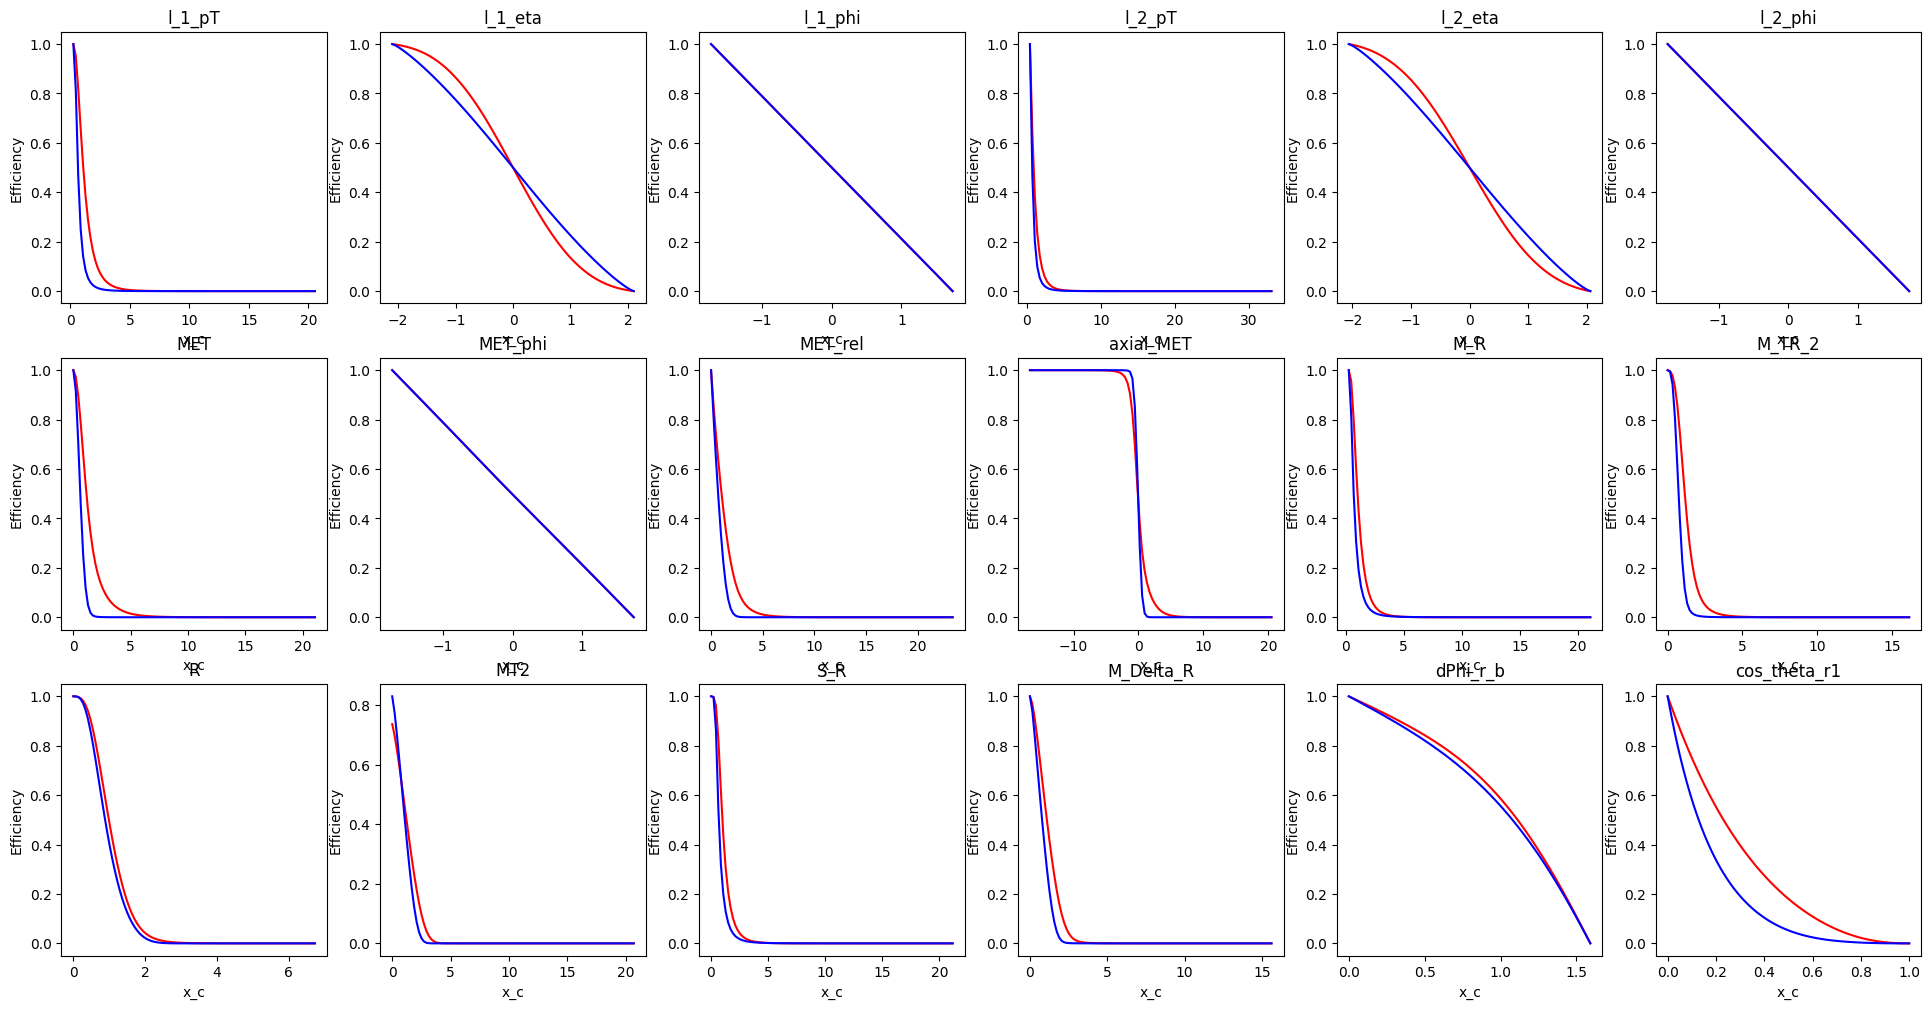

In [33]:
# lets use X > Xc for our distribution
# plot the true positive rate (signal efficiency) vs false positive rate (background efficiency) for different values

# All variables except signal column
all_vars = VarNames[1:]

# Number of threshold points to test
thresholds_n = 100

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for idx, var in enumerate(all_vars):
    thresholds = np.linspace(df[var].min(), df[var].max(), thresholds_n)
    
    tpr = []
    fpr = []
    
    for xc in thresholds:
        tpr.append((df_sig[var] > xc).sum() / len(df_sig))
        fpr.append((df_bkg[var] > xc).sum() / len(df_bkg))
    
    axes[idx].plot(thresholds, tpr, color='red', label='Signal efficiency εS')
    axes[idx].plot(thresholds, fpr, color='blue', label='Background efficiency εB')
    
    axes[idx].set_title(var)
    axes[idx].set_xlabel('x_c')
    axes[idx].set_ylabel('Efficiency')

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

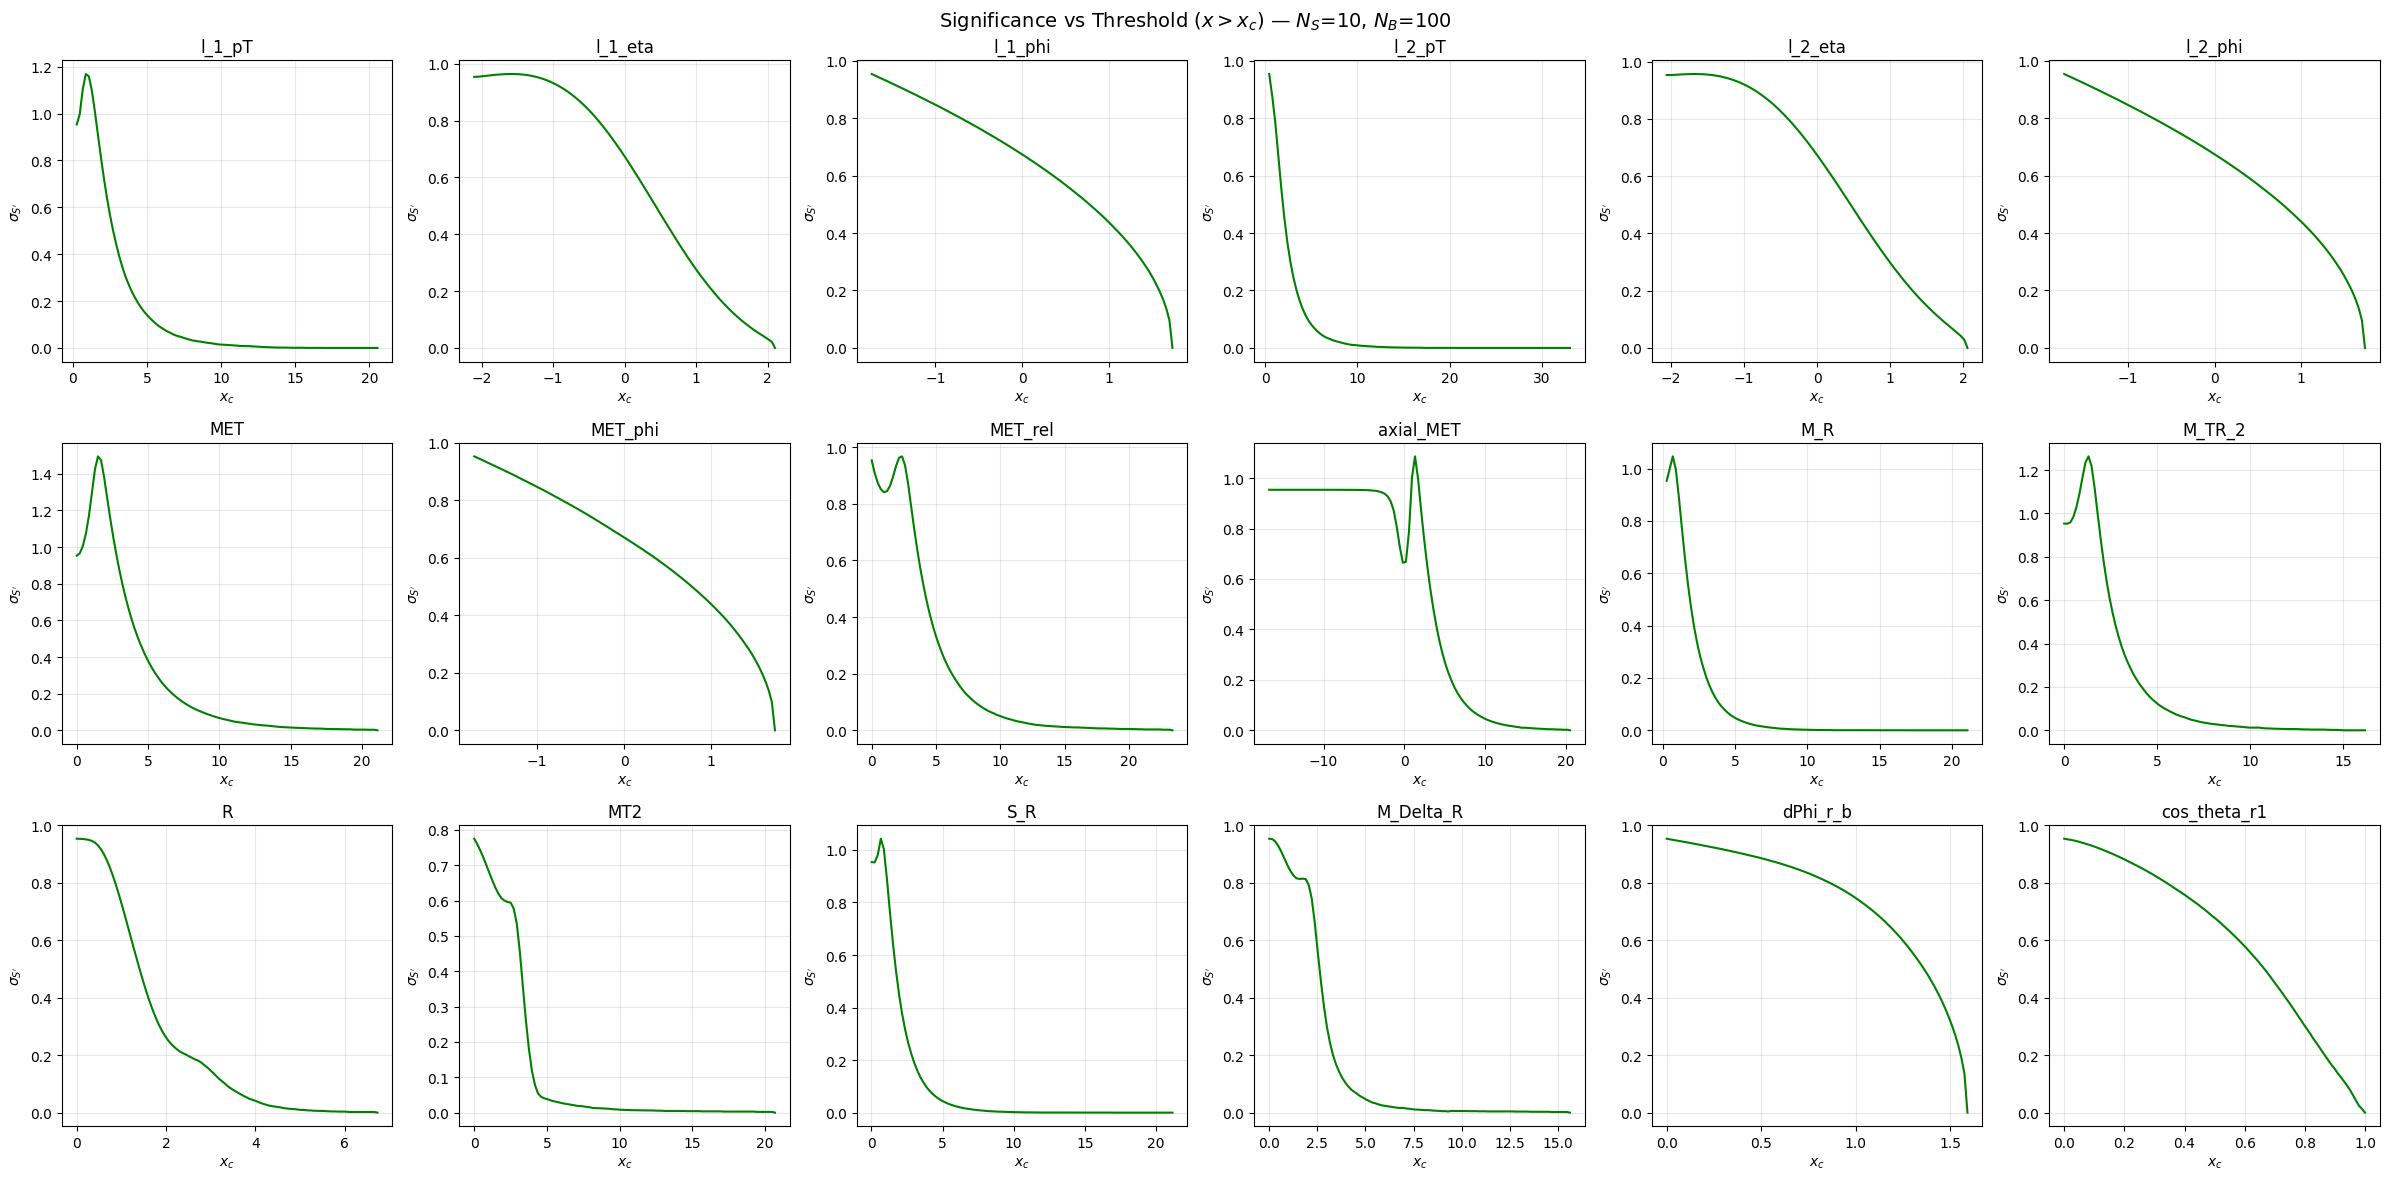

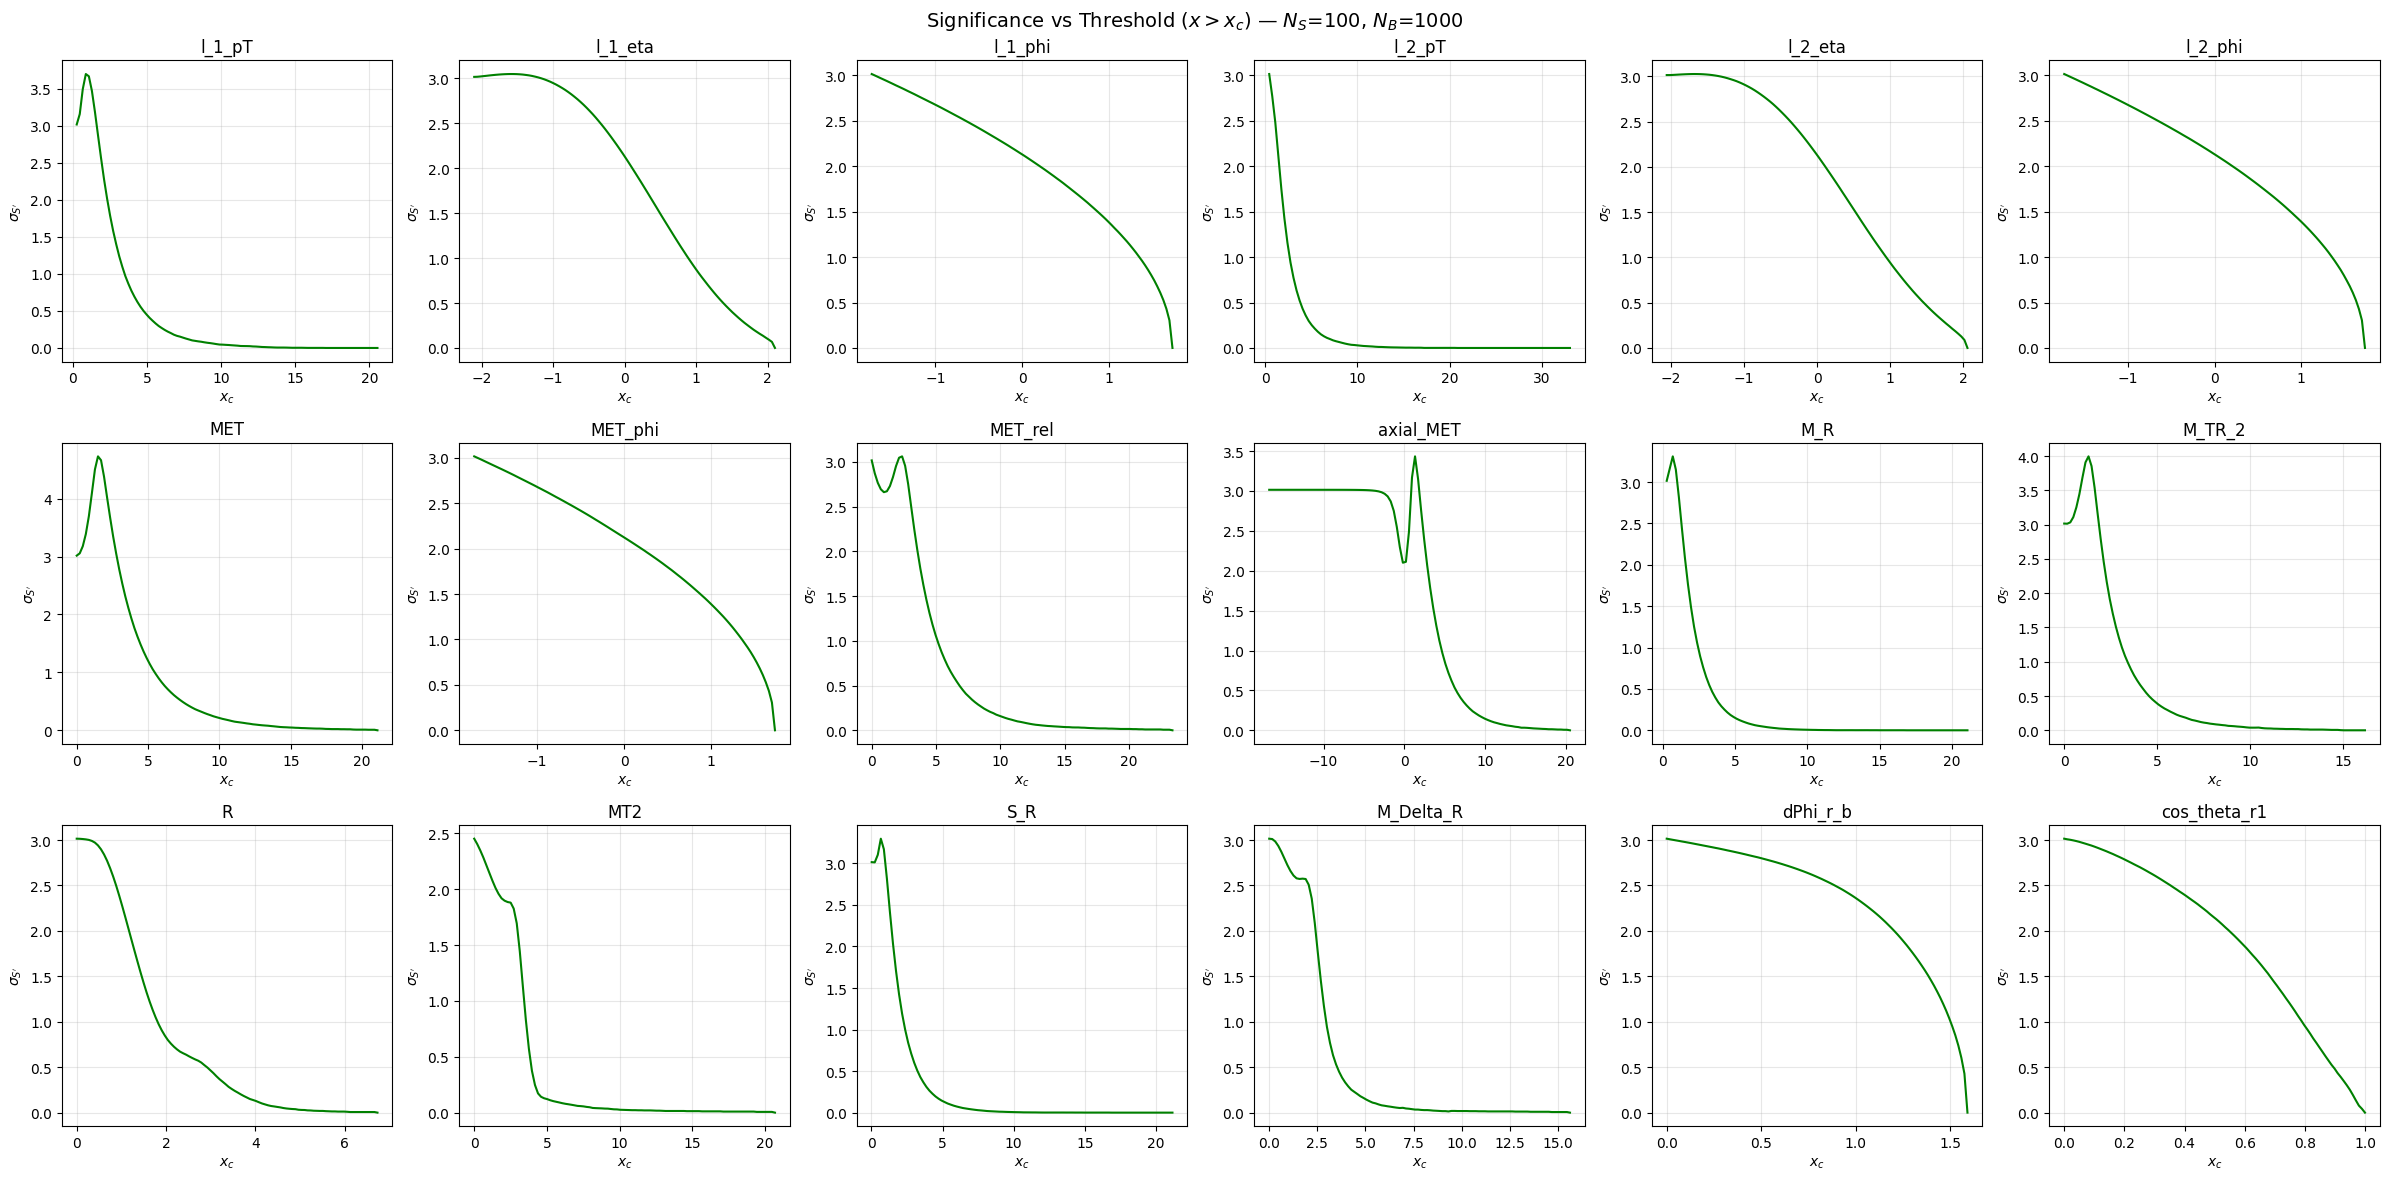

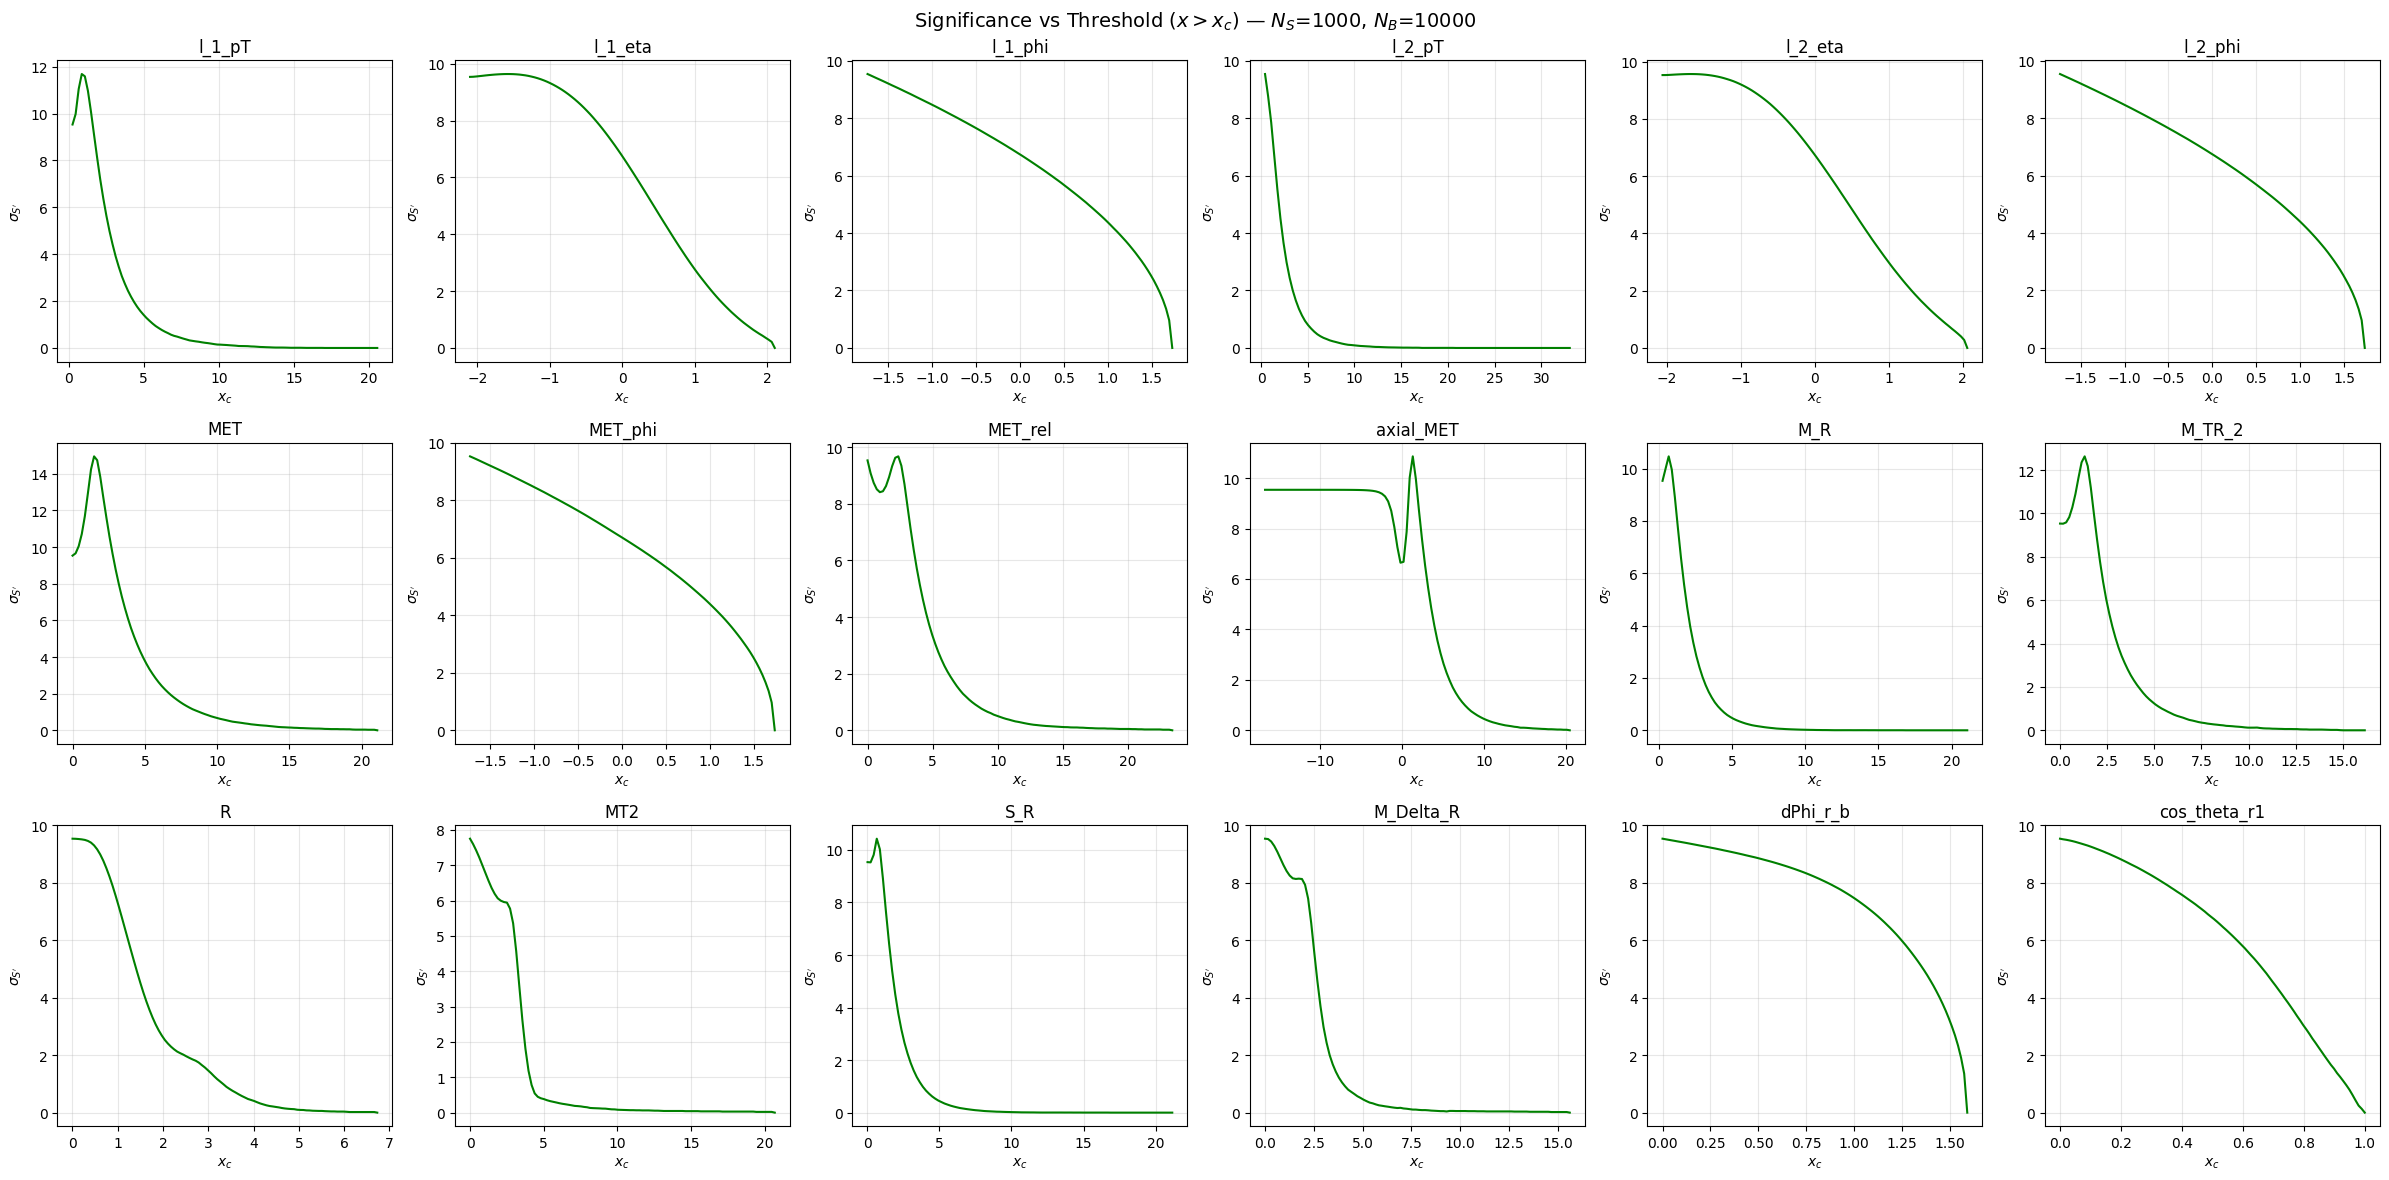

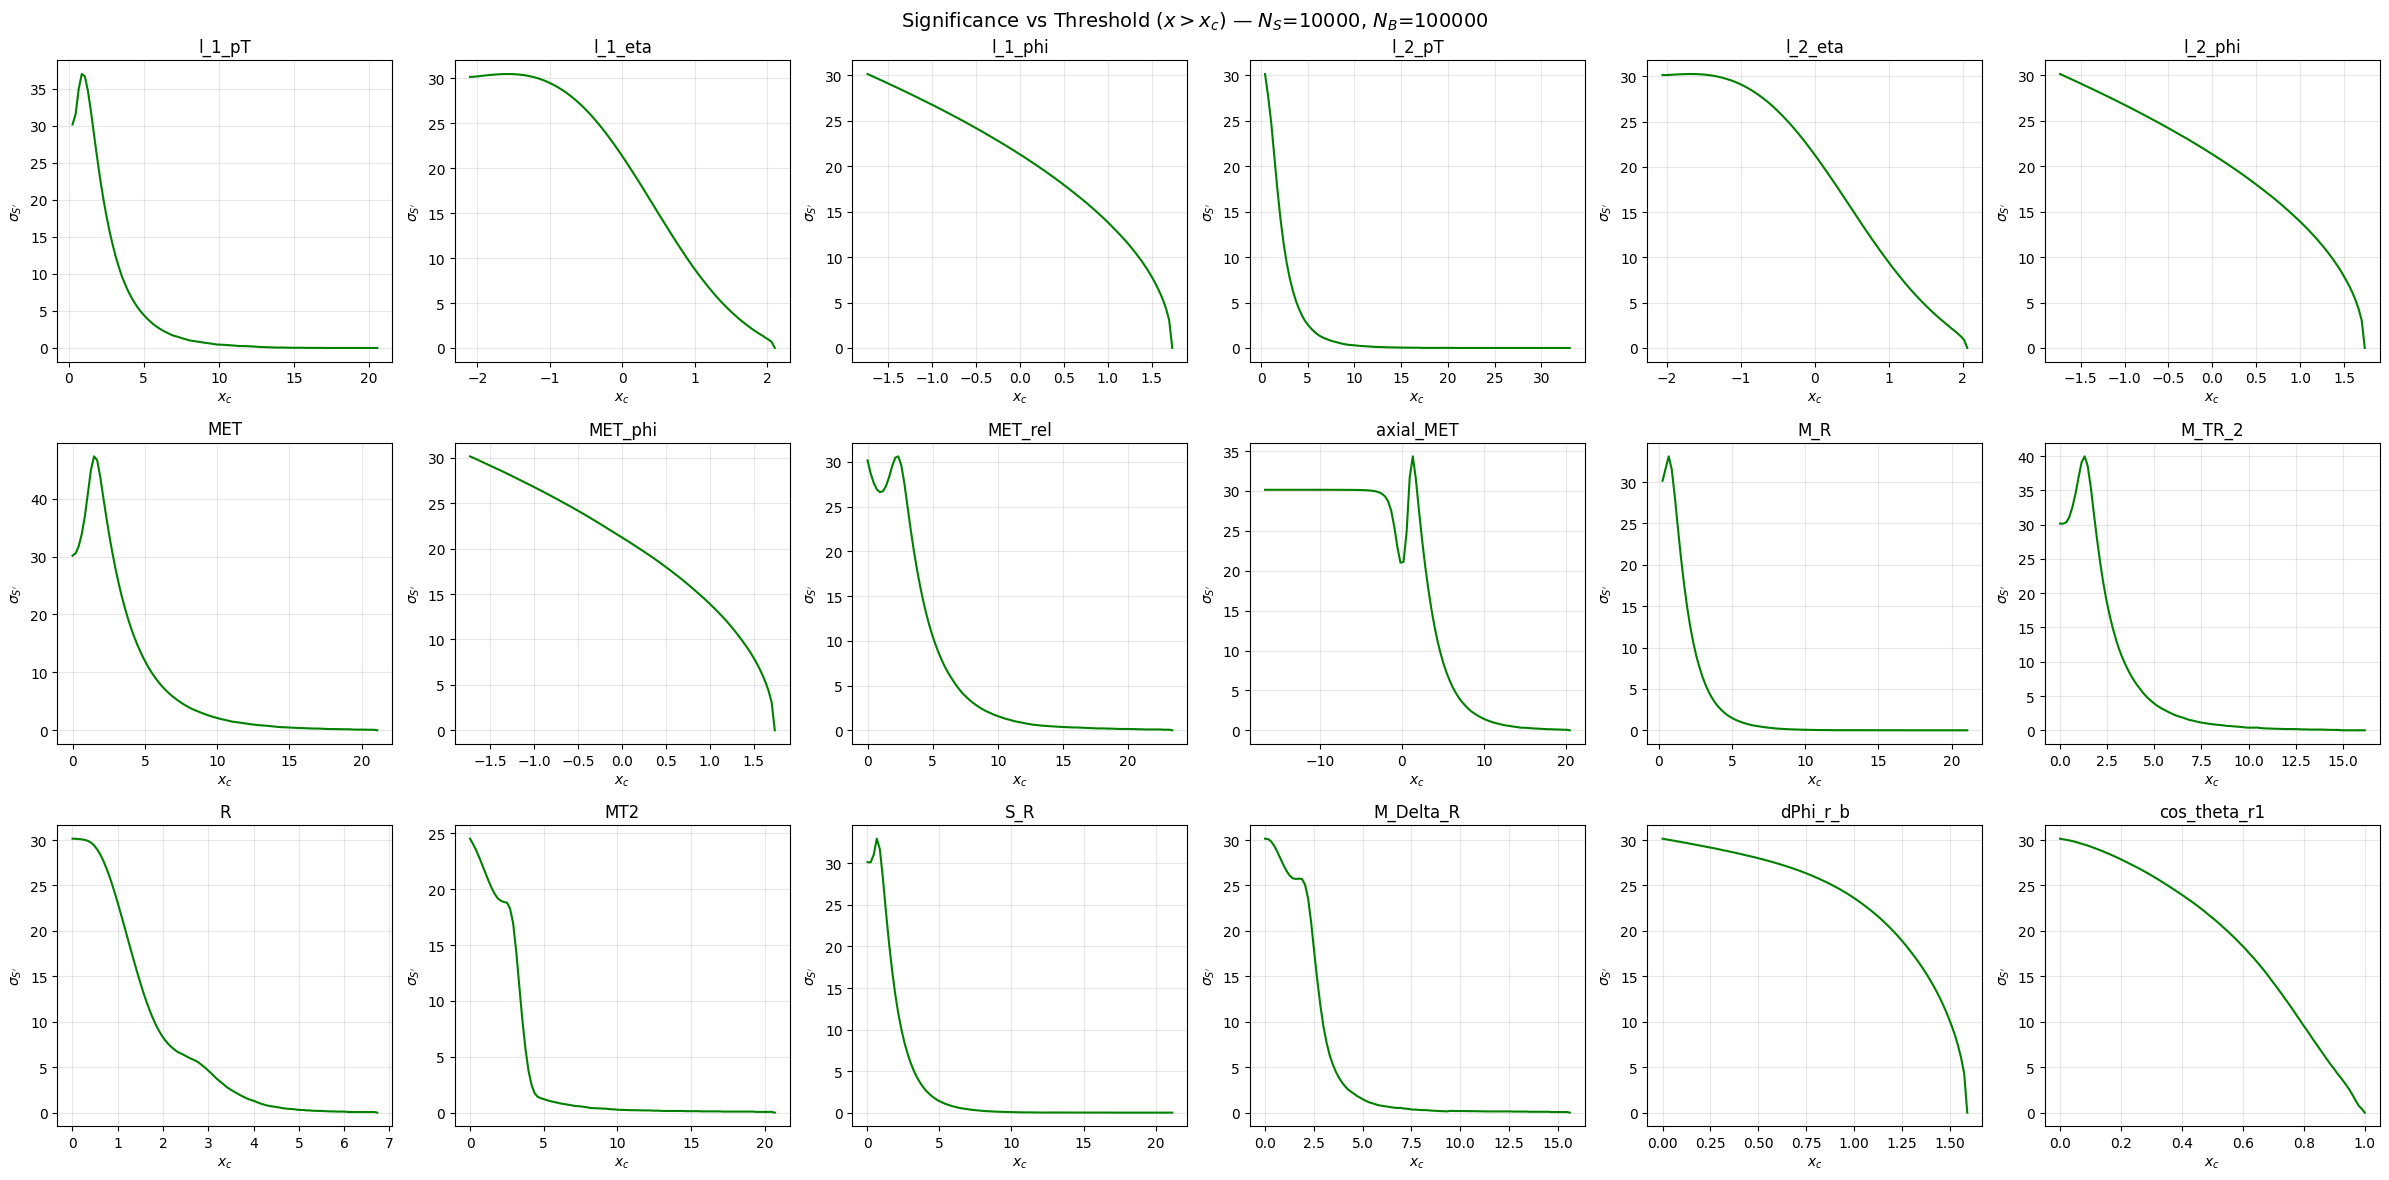

In [34]:
# Exercise 5.3: Significance plots for each scenario

all_vars = VarNames[1:]
thresholds_n = 100

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000),
]

for NS, NB in scenarios:
    fig, axes = plt.subplots(3, 6, figsize=(24, 12))
    axes = axes.flatten()
    
    for idx, var in enumerate(all_vars):
        thresholds = np.linspace(df[var].min(), df[var].max(), thresholds_n)
        significances = []
        
        for xc in thresholds:
            eps_s = (df_sig[var] > xc).sum() / len(df_sig)
            eps_b = (df_bkg[var] > xc).sum() / len(df_bkg)
            
            Ns_prime = eps_s * NS
            Nb_prime = eps_b * NB
            
            if Ns_prime + Nb_prime > 0:
                sig = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
            else:
                sig = 0.0
            
            significances.append(sig)
        
        axes[idx].plot(thresholds, significances, color='green')
        axes[idx].set_title(var)
        axes[idx].set_xlabel('$x_c$')
        axes[idx].set_ylabel('$\\sigma_{S\'}$')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(all_vars), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Significance vs Threshold ($x > x_c$) — $N_S$={NS}, $N_B$={NB}', fontsize=14)
    plt.tight_layout()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 




In [35]:
# Exercise 6.1: For each scenario, find the optimal x_c for each variable
# and choose 3 observables with the highest significance

all_vars = VarNames[1:]
thresholds_n = 100

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000),
]

# Store optimal cuts for each scenario
optimal_cuts = {}

for NS, NB in scenarios:
    best = []  # (var, best_xc, best_significance)
    
    for var in all_vars:
        thresholds = np.linspace(df[var].min(), df[var].max(), thresholds_n)
        
        best_sig = 0.0
        best_xc = thresholds[0]
        
        for xc in thresholds:
            eps_s = (df_sig[var] > xc).sum() / len(df_sig)
            eps_b = (df_bkg[var] > xc).sum() / len(df_bkg)
            
            Ns_prime = eps_s * NS
            Nb_prime = eps_b * NB
            
            if Ns_prime + Nb_prime > 0:
                sig = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
            else:
                sig = 0.0
            
            if sig > best_sig:
                best_sig = sig
                best_xc = xc
        
        # append AFTER finishing threshold loop (this was your bug)
        best.append((var, best_xc, best_sig))
    
    # Sort by significance descending and pick top 3
    best.sort(key=lambda x: x[2], reverse=True)
    optimal_cuts[(NS, NB)] = best[:3]
    
    print(f"\nScenario NS={NS}, NB={NB} — Top 3 observables:")
    
    headers = ["Observable", "Optimal x_c", "Max Significance"]
    print(tabulate.tabulate(
        [(v, f"{xc:.4f}", f"{s:.4f}") for v, xc, s in best[:3]],
        headers=headers,
        tablefmt="grid"
    ))


Scenario NS=10, NB=100 — Top 3 observables:
+--------------+---------------+--------------------+
| Observable   |   Optimal x_c |   Max Significance |
+==============+===============+====================+
| MET          |        1.49   |             1.4954 |
+--------------+---------------+--------------------+
| M_TR_2       |        1.3074 |             1.2634 |
+--------------+---------------+--------------------+
| l_1_pT       |        0.87   |             1.1688 |
+--------------+---------------+--------------------+

Scenario NS=100, NB=1000 — Top 3 observables:
+--------------+---------------+--------------------+
| Observable   |   Optimal x_c |   Max Significance |
+==============+===============+====================+
| MET          |        1.49   |             4.7288 |
+--------------+---------------+--------------------+
| M_TR_2       |        1.3074 |             3.9953 |
+--------------+---------------+--------------------+
| l_1_pT       |        0.87   |            

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

In [36]:
# Exercise 6.2: Cut-flow table for each scenario
# Successively apply selections and tabulate eps_S, eps_B, N'_S, N'_B, sigma_S'

for NS, NB in scenarios:
    cuts = optimal_cuts[(NS, NB)]  # top 3 (var, xc, sig)
    
    # Start with all events
    sig_mask = pd.Series([True] * len(df_sig), index=df_sig.index)
    bkg_mask = pd.Series([True] * len(df_bkg), index=df_bkg.index)
    
    table_rows = []
    
    # No cuts row
    eps_s = sig_mask.sum() / len(df_sig)
    eps_b = bkg_mask.sum() / len(df_bkg)
    
    Ns_prime = eps_s * NS
    Nb_prime = eps_b * NB
    
    sigma = Ns_prime / np.sqrt(Ns_prime + Nb_prime) if (Ns_prime + Nb_prime) > 0 else 0
    
    table_rows.append([
        "No cuts",
        f"{eps_s:.4f}",
        f"{eps_b:.4f}",
        f"{Ns_prime:.2f}",
        f"{Nb_prime:.2f}",
        f"{sigma:.4f}"
    ])
    
    # Successively apply each cut
    for var, xc, _ in cuts:
        sig_mask = sig_mask & (df_sig[var] > xc)
        bkg_mask = bkg_mask & (df_bkg[var] > xc)
        
        eps_s = sig_mask.sum() / len(df_sig)
        eps_b = bkg_mask.sum() / len(df_bkg)
        
        Ns_prime = eps_s * NS
        Nb_prime = eps_b * NB
        
        sigma = Ns_prime / np.sqrt(Ns_prime + Nb_prime) if (Ns_prime + Nb_prime) > 0 else 0
        
        table_rows.append([
            f"{var} > {xc:.4f}",
            f"{eps_s:.4f}",
            f"{eps_b:.4f}",
            f"{Ns_prime:.2f}",
            f"{Nb_prime:.2f}",
            f"{sigma:.4f}"
        ])
    
    print(f"\n=== Cut-Flow Table: NS={NS}, NB={NB} ===")
    
    headers = ["Selection", "εS", "εB", "N'S", "N'B", "σS'"]
    display(HTML(tabulate.tabulate(table_rows, headers=headers, tablefmt="html")))
    


=== Cut-Flow Table: NS=10, NB=100 ===


Selection,εS,εB,N'S,N'B,σS'
No cuts,1,1,10,100,0.9535
MET > 1.4900,0.3438,0.0185,3.44,1.85,1.4954
M_TR_2 > 1.3074,0.2487,0.0132,2.49,1.32,1.2748
l_1_pT > 0.8700,0.2117,0.0094,2.12,0.94,1.2103



=== Cut-Flow Table: NS=100, NB=1000 ===


Selection,εS,εB,N'S,N'B,σS'
No cuts,1,1,100,1000,3.0151
MET > 1.4900,0.3438,0.0185,34.38,18.48,4.7288
M_TR_2 > 1.3074,0.2487,0.0132,24.87,13.18,4.0312
l_1_pT > 0.8700,0.2117,0.0094,21.17,9.43,3.8274



=== Cut-Flow Table: NS=1000, NB=10000 ===


Selection,εS,εB,N'S,N'B,σS'
No cuts,1,1,1000,10000,9.5346
MET > 1.4900,0.3438,0.0185,343.83,184.84,14.9538
M_TR_2 > 1.3074,0.2487,0.0132,248.66,131.83,12.7479
l_1_pT > 0.8700,0.2117,0.0094,211.74,94.31,12.1033



=== Cut-Flow Table: NS=10000, NB=100000 ===


Selection,εS,εB,N'S,N'B,σS'
No cuts,1,1,10000,100000,30.1511
MET > 1.4900,0.3438,0.0185,3438.29,1848.37,47.2881
M_TR_2 > 1.3074,0.2487,0.0132,2486.62,1318.28,40.3123
l_1_pT > 0.8700,0.2117,0.0094,2117.37,943.08,38.274


### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?


In [37]:
# Exercise 6.3: Investigate correlation effects on successive cuts

# Compare: cut on var1 first then optimize var2, vs cut on var2 first then optimize var1
# Use the first scenario as example

NS, NB = 100, 1000
cuts = optimal_cuts[(NS, NB)]

# Pick the top 3 variables
chosen_vars = [c[0] for c in cuts]
print(f"Chosen variables: {chosen_vars}")

# Show correlation between chosen variables
print("\nCorrelation between chosen variables:")
corr_headers = [""] + chosen_vars
corr_rows = []

for i, vi in enumerate(chosen_vars):
    row = [vi]
    for j, vj in enumerate(chosen_vars):
        ii = VarNames[1:].index(vi)
        jj = VarNames[1:].index(vj)
        row.append(f"{Corr_all[ii, jj]:.4f}")
    corr_rows.append(row)

print(tabulate.tabulate(corr_rows, headers=corr_headers, tablefmt="grid"))

# Pick the 2 most correlated (off-diagonal) pair
max_corr = 0
pair = (0, 1)

for i in range(len(chosen_vars)):
    for j in range(i + 1, len(chosen_vars)):
        ii = VarNames[1:].index(chosen_vars[i])
        jj = VarNames[1:].index(chosen_vars[j])
        c = abs(Corr_all[ii, jj])
        
        if c > max_corr:
            max_corr = c
            pair = (i, j)

var1, xc1 = cuts[pair[0]][0], cuts[pair[0]][1]
var2, xc2 = cuts[pair[1]][0], cuts[pair[1]][1]

print(f"\nMost correlated pair: {var1} and {var2} (|ρ| = {max_corr:.4f})")

# --- Order A: cut var1 first, then re-optimize var2 ---
sig_after1 = df_sig[df_sig[var1] > xc1]
bkg_after1 = df_bkg[df_bkg[var1] > xc1]

thresholds2 = np.linspace(df[var2].min(), df[var2].max(), thresholds_n)

best_sig_a = 0
best_xc2_a = thresholds2[0]

for xc in thresholds2:
    es = (sig_after1[var2] > xc).sum() / len(df_sig)
    eb = (bkg_after1[var2] > xc).sum() / len(df_bkg)
    
    Nsp = es * NS
    Nbp = eb * NB
    
    s = Nsp / np.sqrt(Nsp + Nbp) if (Nsp + Nbp) > 0 else 0
    
    if s > best_sig_a:
        best_sig_a = s
        best_xc2_a = xc

print(f"\nOrder A: Cut {var1} > {xc1:.4f} first, then optimize {var2}")
print(f" Re-optimized {var2} threshold: {best_xc2_a:.4f}")
print(f" Combined significance: {best_sig_a:.4f}")

# --- Order B: cut var2 first, then re-optimize var1 ---
sig_after2 = df_sig[df_sig[var2] > xc2]
bkg_after2 = df_bkg[df_bkg[var2] > xc2]

thresholds1 = np.linspace(df[var1].min(), df[var1].max(), thresholds_n)

best_sig_b = 0
best_xc1_b = thresholds1[0]

for xc in thresholds1:
    es = (sig_after2[var1] > xc).sum() / len(df_sig)
    eb = (bkg_after2[var1] > xc).sum() / len(df_bkg)
    
    Nsp = es * NS
    Nbp = eb * NB
    
    s = Nsp / np.sqrt(Nsp + Nbp) if (Nsp + Nbp) > 0 else 0
    
    if s > best_sig_b:
        best_sig_b = s
        best_xc1_b = xc

print(f"\nOrder B: Cut {var2} > {xc2:.4f} first, then optimize {var1}")
print(f" Re-optimized {var1} threshold: {best_xc1_b:.4f}")
print(f" Combined significance: {best_sig_b:.4f}")

print(f"\nDifference in significance: {abs(best_sig_a - best_sig_b):.4f}")

if abs(best_sig_a - best_sig_b) > 0.01:
    print("The order of cuts matters — correlated variables lead to different results depending on cut order.")
else:
    print("The order of cuts has minimal effect for these variables.")

Chosen variables: ['MET', 'M_TR_2', 'l_1_pT']

Correlation between chosen variables:
+--------+--------+----------+----------+
|        |    MET |   M_TR_2 |   l_1_pT |
+========+========+==========+==========+
| MET    | 1      |   0.722  |   0.3849 |
+--------+--------+----------+----------+
| M_TR_2 | 0.722  |   1      |   0.7244 |
+--------+--------+----------+----------+
| l_1_pT | 0.3849 |   0.7244 |   1      |
+--------+--------+----------+----------+

Most correlated pair: M_TR_2 and l_1_pT (|ρ| = 0.7244)

Order A: Cut M_TR_2 > 1.3074 first, then optimize l_1_pT
 Re-optimized l_1_pT threshold: 0.2549
 Combined significance: 3.9953

Order B: Cut l_1_pT > 0.8700 first, then optimize M_TR_2
 Re-optimized M_TR_2 threshold: 1.1441
 Combined significance: 3.8142

Difference in significance: 0.1811
The order of cuts matters — correlated variables lead to different results depending on cut order.


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.



/var/folders/f9/jsb45pg91jl516lqxkh0212m0000gn/T/ipykernel_27721/1587097915.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(tpr_sorted, fpr_sorted)


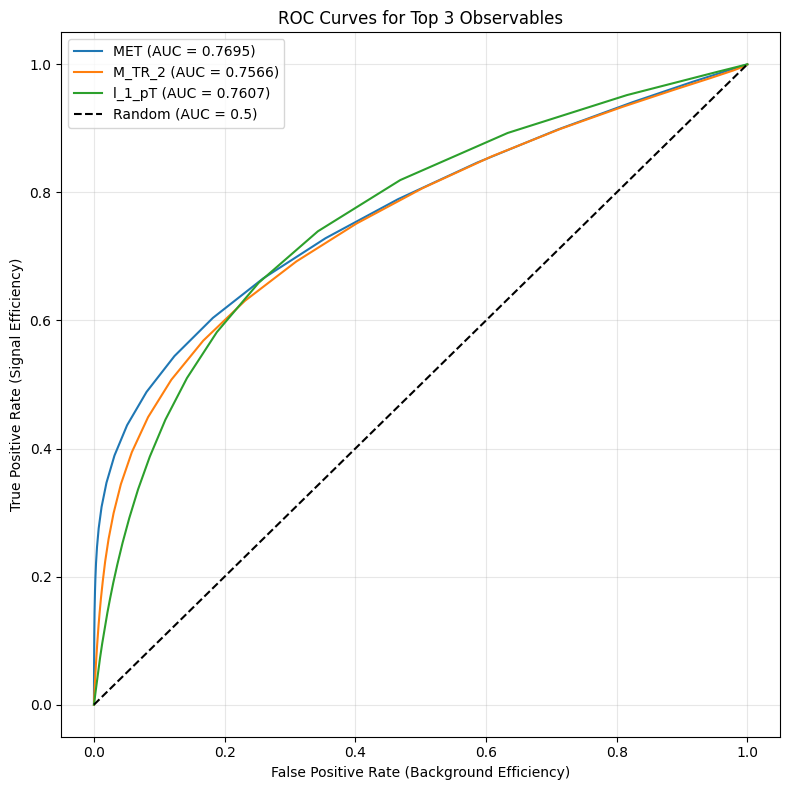

In [38]:
# Exercise 7.1: ROC curves for top 3 observables with AUC, without sklearn

# Use top 3 from optimal_cuts for scenario NS=100, NB=1000
top3 = optimal_cuts[(100, 1000)]
top3_vars = [c[0] for c in top3]

thresholds_n = 200

fig, ax = plt.subplots(figsize=(8, 8))

for var in top3_vars:
    thresholds = np.linspace(df[var].min(), df[var].max(), thresholds_n)
    
    tpr_vals = []
    fpr_vals = []
    
    for xc in thresholds:
        tpr_vals.append((df_sig[var] > xc).sum() / len(df_sig))
        fpr_vals.append((df_bkg[var] > xc).sum() / len(df_bkg))
    
    fpr_vals = np.array(fpr_vals)
    tpr_vals = np.array(tpr_vals)
    
    # Sort by FPR for plotting and AUC
    order = np.argsort(fpr_vals)
    fpr_sorted = fpr_vals[order]
    tpr_sorted = tpr_vals[order]
    
    # Add endpoints if needed
    if fpr_sorted[0] > 0 or tpr_sorted[0] > 0:
        fpr_sorted = np.insert(fpr_sorted, 0, 0.0)
        tpr_sorted = np.insert(tpr_sorted, 0, 0.0)
    
    if fpr_sorted[-1] < 1 or tpr_sorted[-1] < 1:
        fpr_sorted = np.append(fpr_sorted, 1.0)
        tpr_sorted = np.append(tpr_sorted, 1.0)
    
    # AUC using trapezoidal rule
    area = np.trapz(tpr_sorted, fpr_sorted)
    
    ax.plot(fpr_sorted, tpr_sorted, label=f"{var} (AUC = {area:.4f})")

# Random classifier line
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")

ax.set_xlabel("False Positive Rate (Background Efficiency)")
ax.set_ylabel("True Positive Rate (Signal Efficiency)")
ax.set_title("ROC Curves for Top 3 Observables")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.



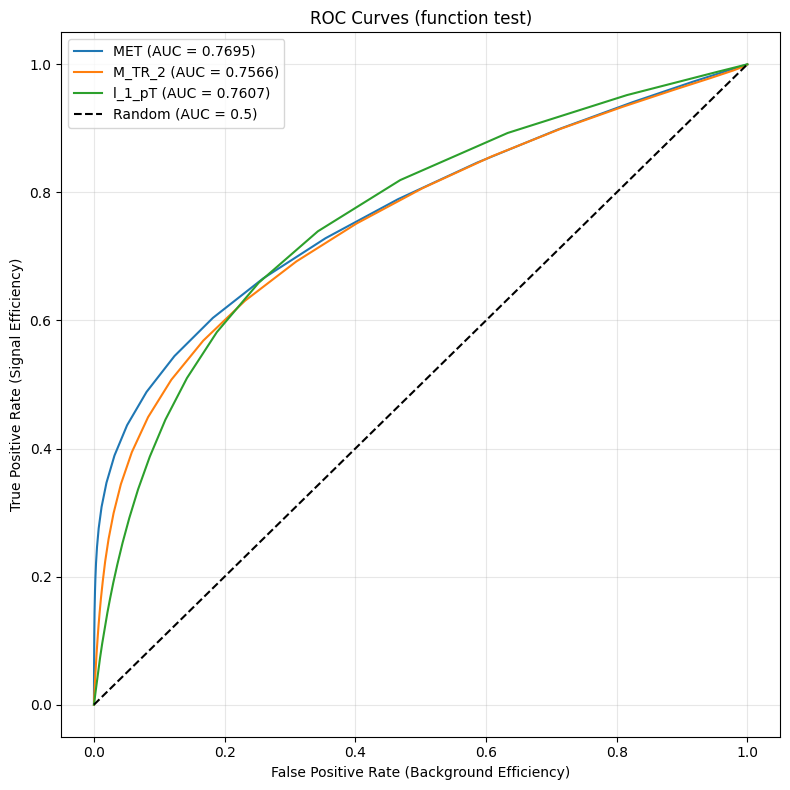

AUC values: {'MET': np.float64(0.76946325477972), 'M_TR_2': np.float64(0.7566419412949237), 'l_1_pT': np.float64(0.7607191176819005)}


In [39]:
# Exercise 7.2: Reusable ROC curve function

def plot_roc_curves(variables, sig_df, bkg_df, title="ROC Curves", n_thresholds=200, ax=None):
    """
    Plot overlaid ROC curves for given variables.

    Parameters:
        variables: list of column names to plot ROC curves for
        sig_df: DataFrame of signal events
        bkg_df: DataFrame of background events
        title: plot title
        n_thresholds: number of threshold points
        ax: matplotlib axes (creates new figure if None)

    Returns:
        dict of {variable: AUC}
    """
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    auc_values = {}
    
    for var in variables:
        all_vals = pd.concat([sig_df[var], bkg_df[var]])
        thresholds = np.linspace(all_vals.min(), all_vals.max(), n_thresholds)
        
        tpr_vals = []
        fpr_vals = []
        
        for xc in thresholds:
            tpr_vals.append((sig_df[var] > xc).sum() / len(sig_df))
            fpr_vals.append((bkg_df[var] > xc).sum() / len(bkg_df))
        
        # Sort pairs
        sorted_pairs = sorted(zip(fpr_vals, tpr_vals))
        fpr_sorted = [p[0] for p in sorted_pairs]
        tpr_sorted = [p[1] for p in sorted_pairs]
        
        area = auc(fpr_sorted, tpr_sorted)
        auc_values[var] = area
        
        ax.plot(fpr_sorted, tpr_sorted, label=f'{var} (AUC = {area:.4f})')
    
    # Random classifier line (only once)
    ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
    
    ax.set_xlabel('False Positive Rate (Background Efficiency)')
    ax.set_ylabel('True Positive Rate (Signal Efficiency)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return auc_values


# Helper for AUC
def _compute_auc(y, x):
    return np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x)


# Fix missing auc() used inside plot_roc_curves
def auc(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    
    if x[0] > 0 or y[0] > 0:
        x = np.insert(x, 0, 0.0)
        y = np.insert(y, 0, 0.0)
    
    if x[-1] < 1 or y[-1] < 1:
        x = np.append(x, 1.0)
        y = np.append(y, 1.0)
    
    return _compute_auc(y, x)


# Quick test
auc_vals = plot_roc_curves(top3_vars, df_sig, df_bkg, title="ROC Curves (function test)")

plt.tight_layout()
plt.show()

print("AUC values:", auc_vals)

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

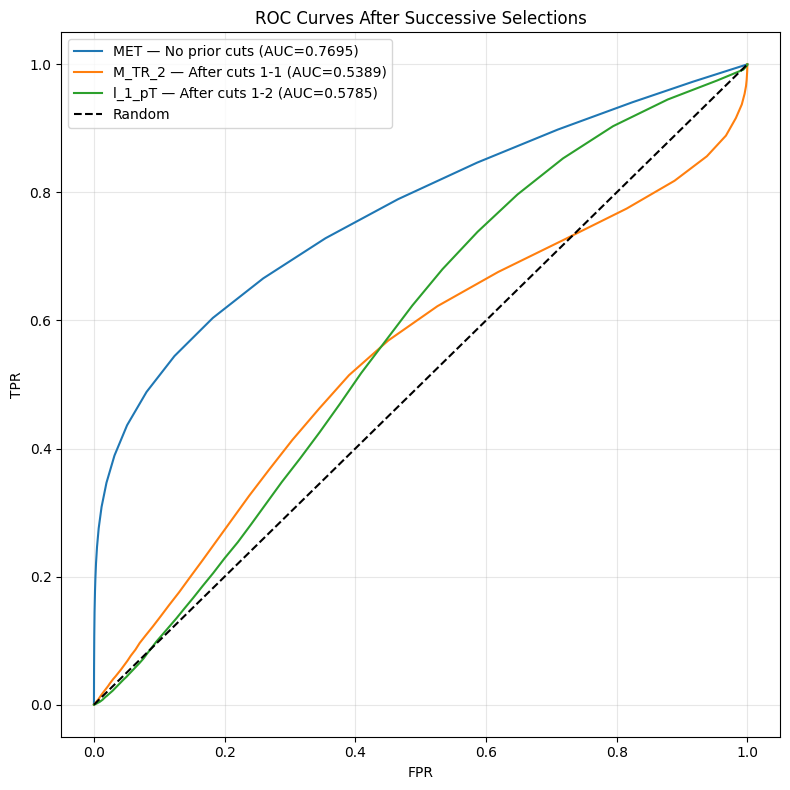

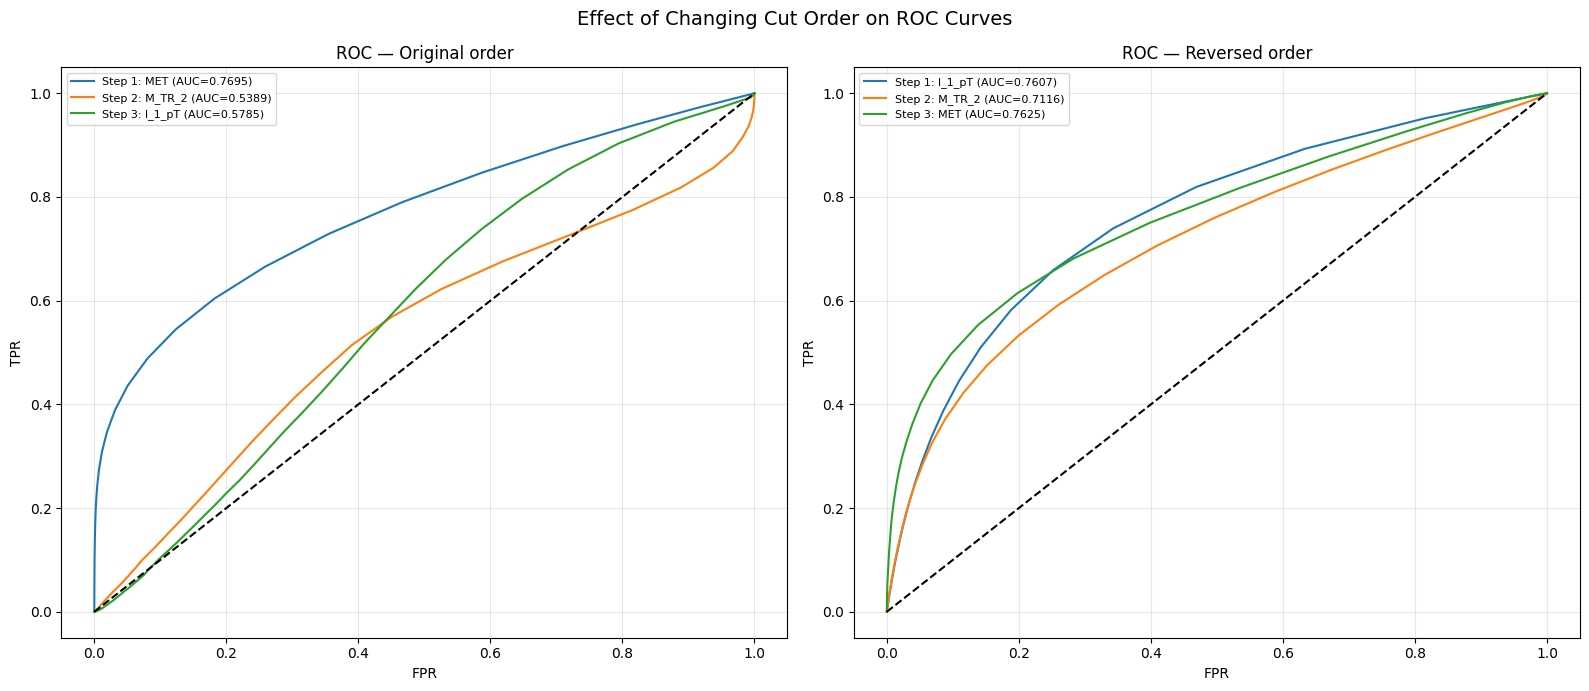

In [40]:
# Exercise 7.3: ROC curves after successive selections from Exercise 6

NS, NB = 100, 1000
cuts = optimal_cuts[(NS, NB)]

fig, ax = plt.subplots(figsize=(8, 8))

sig_remaining = df_sig.copy()
bkg_remaining = df_bkg.copy()

for step in range(len(cuts)):
    var, xc, _ = cuts[step]
    
    label_prefix = f"After cuts 1-{step}" if step > 0 else "No prior cuts"
    
    thresholds = np.linspace(df[var].min(), df[var].max(), 200)
    
    tpr_vals = []
    fpr_vals = []
    
    for t in thresholds:
        if len(sig_remaining) > 0:
            tpr_vals.append((sig_remaining[var] > t).sum() / len(sig_remaining))
        else:
            tpr_vals.append(0)
        
        if len(bkg_remaining) > 0:
            fpr_vals.append((bkg_remaining[var] > t).sum() / len(bkg_remaining))
        else:
            fpr_vals.append(0)
    
    sorted_pairs = sorted(zip(fpr_vals, tpr_vals))
    fpr_sorted = [p[0] for p in sorted_pairs]
    tpr_sorted = [p[1] for p in sorted_pairs]
    
    area = auc(fpr_sorted, tpr_sorted)
    
    ax.plot(fpr_sorted, tpr_sorted,
            label=f'{var} — {label_prefix} (AUC={area:.4f})')
    
    # Apply cut for next iteration
    sig_remaining = sig_remaining[sig_remaining[var] > xc]
    bkg_remaining = bkg_remaining[bkg_remaining[var] > xc]

# Random line (only once)
ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curves After Successive Selections')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Exercise 7.4: Effect of changing order of successive selections

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for order_idx, order in enumerate([cuts, list(reversed(cuts))]):
    ax = axes[order_idx]
    
    sig_rem = df_sig.copy()
    bkg_rem = df_bkg.copy()
    
    order_label = "Original order" if order_idx == 0 else "Reversed order"
    
    for step in range(len(order)):
        var, xc, _ = order[step]
        
        thresholds = np.linspace(df[var].min(), df[var].max(), 200)
        
        tpr_vals = []
        fpr_vals = []
        
        for t in thresholds:
            if len(sig_rem) > 0:
                tpr_vals.append((sig_rem[var] > t).sum() / len(sig_rem))
            else:
                tpr_vals.append(0)
            
            if len(bkg_rem) > 0:
                fpr_vals.append((bkg_rem[var] > t).sum() / len(bkg_rem))
            else:
                fpr_vals.append(0)
        
        sorted_pairs = sorted(zip(fpr_vals, tpr_vals))
        fpr_sorted = [p[0] for p in sorted_pairs]
        tpr_sorted = [p[1] for p in sorted_pairs]
        
        area = auc(fpr_sorted, tpr_sorted)
        
        ax.plot(fpr_sorted, tpr_sorted,
                label=f'Step {step+1}: {var} (AUC={area:.4f})')
        
        # Apply cut
        sig_rem = sig_rem[sig_rem[var] > xc]
        bkg_rem = bkg_rem[bkg_rem[var] > xc]
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {order_label}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Changing Cut Order on ROC Curves', fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.


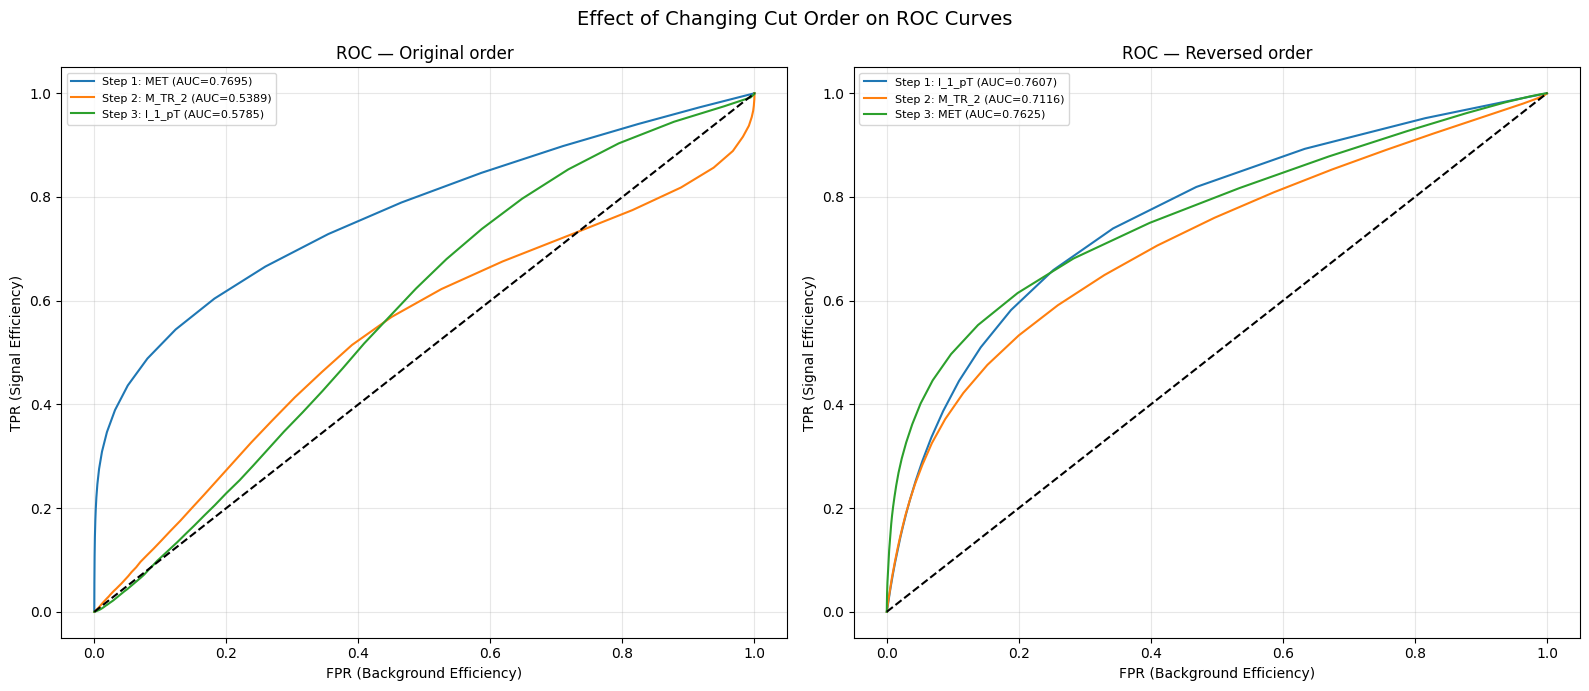

In [41]:
 # Exercise 7.4: Effect of changing order of successive selections

NS, NB = 100, 1000
cuts = optimal_cuts[(NS, NB)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for order_idx, order in enumerate([cuts, list(reversed(cuts))]):
    ax = axes[order_idx]
    
    sig_rem = df_sig.copy()
    bkg_rem = df_bkg.copy()
    
    order_label = "Original order" if order_idx == 0 else "Reversed order"
    
    for step in range(len(order)):
        var, xc, _ = order[step]
        
        thresholds = np.linspace(df[var].min(), df[var].max(), 200)
        
        tpr_vals = []
        fpr_vals = []
        
        for t in thresholds:
            if len(sig_rem) > 0:
                tpr_vals.append((sig_rem[var] > t).sum() / len(sig_rem))
            else:
                tpr_vals.append(0)
            
            if len(bkg_rem) > 0:
                fpr_vals.append((bkg_rem[var] > t).sum() / len(bkg_rem))
            else:
                fpr_vals.append(0)
        
        sorted_pairs = sorted(zip(fpr_vals, tpr_vals))
        fpr_sorted = [p[0] for p in sorted_pairs]
        tpr_sorted = [p[1] for p in sorted_pairs]
        
        area = auc(fpr_sorted, tpr_sorted)
        
        ax.plot(fpr_sorted, tpr_sorted,
                label=f'Step {step+1}: {var} (AUC={area:.4f})')
        
        # Apply cut
        sig_rem = sig_rem[sig_rem[var] > xc]
        bkg_rem = bkg_rem[bkg_rem[var] > xc]
    
    # Random line (only once per subplot)
    ax.plot([0, 1], [0, 1], 'k--')
    
    ax.set_xlabel('FPR (Background Efficiency)')
    ax.set_ylabel('TPR (Signal Efficiency)')
    ax.set_title(f'ROC — {order_label}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Changing Cut Order on ROC Curves', fontsize=14)
plt.tight_layout()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [42]:
# Exercise 8.1: Compute between-class S_B and within-class S_W

feature_vars = VarNames[1:]

X_sig = df_sig[feature_vars].values
X_bkg = df_bkg[feature_vars].values

# Mean vectors
m1 = X_sig.mean(axis=0)  # signal mean
m2 = X_bkg.mean(axis=0)  # background mean

# Between-class scatter matrix: S_B = (m2 - m1)(m2 - m1)^T
diff = (m2 - m1).reshape(-1, 1)
S_B = diff @ diff.T

# Within-class scatter matrix
X_sig_centered = X_sig - m1
X_bkg_centered = X_bkg - m2

S_W = X_sig_centered.T @ X_sig_centered + X_bkg_centered.T @ X_bkg_centered

print(f"S_B shape: {S_B.shape}")
print(f"S_W shape: {S_W.shape}")

print("\nS_B (between-class scatter matrix):")
display(HTML(tabulate.tabulate(
    S_B,
    headers=feature_vars,
    showindex=feature_vars,
    floatfmt=".4e",
    tablefmt="html"
)))

print("\nS_W (within-class scatter matrix):")
display(HTML(tabulate.tabulate(
    S_W,
    headers=feature_vars,
    showindex=feature_vars,
    floatfmt=".4e",
    tablefmt="html"
)))

S_B shape: (18, 18)
S_W shape: (18, 18)

S_B (between-class scatter matrix):


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,2.8566e-01,-3.5281e-04,-4.9616e-04,1.3672e-01,4.0881e-04,-1.0631e-04,4.1093e-01,1.1783e-04,2.7005e-01,8.2822e-02,1.7985e-01,2.6509e-01,5.6542e-02,7.3211e-02,1.7202e-01,1.8268e-01,1.5278e-02,5.6800e-02
l_1_eta,-3.5281e-04,4.3575e-07,6.1279e-07,-1.6886e-04,-5.0491e-07,1.3130e-07,-5.0753e-04,-1.4553e-07,-3.3353e-04,-1.0229e-04,-2.2213e-04,-3.2741e-04,-6.9833e-05,-9.0421e-05,-2.1246e-04,-2.2563e-04,-1.8869e-05,-7.0151e-05
l_1_phi,-4.9616e-04,6.1279e-07,8.6177e-07,-2.3746e-04,-7.1005e-07,1.8465e-07,-7.1374e-04,-2.0465e-07,-4.6904e-04,-1.4385e-04,-3.1238e-04,-4.6043e-04,-9.8207e-05,-1.2716e-04,-2.9878e-04,-3.1730e-04,-2.6536e-05,-9.8654e-05
l_2_pT,1.3672e-01,-1.6886e-04,-2.3746e-04,6.5434e-02,1.9566e-04,-5.0881e-05,1.9667e-01,5.6393e-05,1.2925e-01,3.9639e-02,8.6077e-02,1.2687e-01,2.7061e-02,3.5039e-02,8.2331e-02,8.7432e-02,7.3121e-03,2.7184e-02
l_2_eta,4.0881e-04,-5.0491e-07,-7.1005e-07,1.9566e-04,5.8504e-07,-1.5214e-07,5.8808e-04,1.6862e-07,3.8646e-04,1.1853e-04,2.5738e-04,3.7937e-04,8.0917e-05,1.0477e-04,2.4618e-04,2.6144e-04,2.1864e-05,8.1286e-05
l_2_phi,-1.0631e-04,1.3130e-07,1.8465e-07,-5.0881e-05,-1.5214e-07,3.9564e-08,-1.5293e-04,-4.3851e-08,-1.0050e-04,-3.0823e-05,-6.6933e-05,-9.8655e-05,-2.1043e-05,-2.7246e-05,-6.4020e-05,-6.7987e-05,-5.6858e-06,-2.1138e-05
MET,4.1093e-01,-5.0753e-04,-7.1374e-04,1.9667e-01,5.8808e-04,-1.5293e-04,5.9114e-01,1.6950e-04,3.8847e-01,1.1914e-01,2.5872e-01,3.8134e-01,8.1338e-02,1.0532e-01,2.4746e-01,2.6280e-01,2.1978e-02,8.1708e-02
MET_phi,1.1783e-04,-1.4553e-07,-2.0465e-07,5.6393e-05,1.6862e-07,-4.3851e-08,1.6950e-04,4.8602e-08,1.1139e-04,3.4162e-05,7.4184e-05,1.0934e-04,2.3322e-05,3.0198e-05,7.0956e-05,7.5353e-05,6.3018e-06,2.3429e-05
MET_rel,2.7005e-01,-3.3353e-04,-4.6904e-04,1.2925e-01,3.8646e-04,-1.0050e-04,3.8847e-01,1.1139e-04,2.5529e-01,7.8296e-02,1.7002e-01,2.5060e-01,5.3452e-02,6.9210e-02,1.6262e-01,1.7270e-01,1.4443e-02,5.3695e-02
axial_MET,8.2822e-02,-1.0229e-04,-1.4385e-04,3.9639e-02,1.1853e-04,-3.0823e-05,1.1914e-01,3.4162e-05,7.8296e-02,2.4013e-02,5.2144e-02,7.6858e-02,1.6393e-02,2.1226e-02,4.9875e-02,5.2966e-02,4.4296e-03,1.6468e-02



S_W (within-class scatter matrix):


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,2.0076e+06,-8.7550e+02,-5.2957e+02,1.3698e+06,-2.0196e+03,1.2678e+03,6.4479e+05,-3.5281e+03,1.5770e+05,-1.6534e+05,1.6172e+06,1.1252e+06,-3.6659e+05,-1.5475e+05,1.5179e+06,2.6371e+05,-2.5408e+05,4.2097e+04
l_1_eta,-8.7550e+02,5.0311e+06,1.6072e+03,-1.6799e+03,2.0294e+06,1.4853e+03,-2.1586e+03,-2.7029e+03,-2.0693e+03,-2.3606e+03,-1.2649e+03,-9.2319e+02,7.2535e+02,-6.7588e+02,-1.1434e+03,-2.2407e+03,4.2166e+02,8.1580e+02
l_1_phi,-5.2957e+02,1.6072e+03,5.0167e+06,-3.4804e+02,3.2065e+03,-1.3407e+06,6.8864e+03,-9.2092e+05,8.2266e+03,-9.6450e+03,-6.1080e+02,4.7603e+03,4.5039e+03,8.9281e+03,5.9558e+02,6.9557e+03,4.8010e+03,1.6199e+03
l_2_pT,1.3698e+06,-1.6799e+03,-3.4804e+02,2.0588e+06,-2.5142e+03,6.3677e+02,1.5445e+05,-7.0103e+03,-1.7169e+05,1.9979e+05,1.5338e+06,6.6448e+05,-5.3016e+05,-3.8918e+05,1.5209e+06,-8.0743e+04,-2.9662e+04,-1.7272e+05
l_2_eta,-2.0196e+03,2.0294e+06,3.2065e+03,-2.5142e+03,5.0284e+06,-3.2344e+02,-4.7386e+02,-6.2817e+02,1.6982e+02,-9.9775e+02,-3.0640e+03,-1.3068e+03,1.1667e+03,-5.8315e+02,-3.0736e+03,-1.3972e+03,-2.8493e+02,8.9262e+02
l_2_phi,1.2678e+03,1.4853e+03,-1.3407e+06,6.3677e+02,-3.2344e+02,5.0163e+06,2.1139e+02,-1.7234e+05,1.1966e+03,-4.1852e+02,1.5172e+03,1.5625e+03,1.1993e+03,6.2513e+03,1.9972e+03,2.5663e+03,1.2254e+03,-9.6678e+02
MET,6.4479e+05,-2.1586e+03,6.8864e+03,1.5445e+05,-4.7386e+02,2.1139e+02,3.0761e+06,-8.3191e+03,2.2597e+06,5.7617e+05,4.0852e+05,1.3672e+06,8.4181e+05,6.5124e+05,5.2955e+05,1.2569e+06,6.9912e+05,2.6489e+05
MET_phi,-3.5281e+03,-2.7029e+03,-9.2092e+05,-7.0103e+03,-6.2817e+02,-1.7234e+05,-8.3191e+03,5.0166e+06,-1.4736e+04,-4.8081e+03,-4.9703e+03,-4.3460e+03,-8.4585e+02,2.4898e+03,-5.7914e+03,-2.0864e+03,-6.6239e+03,2.5980e+02
MET_rel,1.5770e+05,-2.0693e+03,8.2266e+03,-1.7169e+05,1.6982e+02,1.1966e+03,2.2597e+06,-1.4736e+04,3.6452e+06,-7.2353e+05,7.5349e+03,1.2057e+06,1.1812e+06,1.9642e+06,2.1027e+05,1.8641e+06,7.1506e+05,2.1139e+05
axial_MET,-1.6534e+05,-2.3606e+03,-9.6450e+03,1.9979e+05,-9.9775e+02,-4.1852e+02,5.7617e+05,-4.8081e+03,-7.2353e+05,4.9861e+06,1.0812e+04,-1.0391e+06,-9.2854e+05,-2.3279e+06,-2.7898e+05,-1.2362e+06,-1.3654e+05,-2.9106e+05


Linear coefficients w:
         l_1_pT: -0.000000
        l_1_eta: 0.000000
        l_1_phi: 0.000000
         l_2_pT: -0.000000
        l_2_eta: -0.000000
        l_2_phi: 0.000000
            MET: -0.000000
        MET_phi: -0.000000
        MET_rel: -0.000000
      axial_MET: -0.000000
            M_R: 0.000000
         M_TR_2: -0.000000
              R: 0.000000
            MT2: 0.000000
            S_R: 0.000000
      M_Delta_R: -0.000000
       dPhi_r_b: 0.000000
   cos_theta_r1: -0.000001


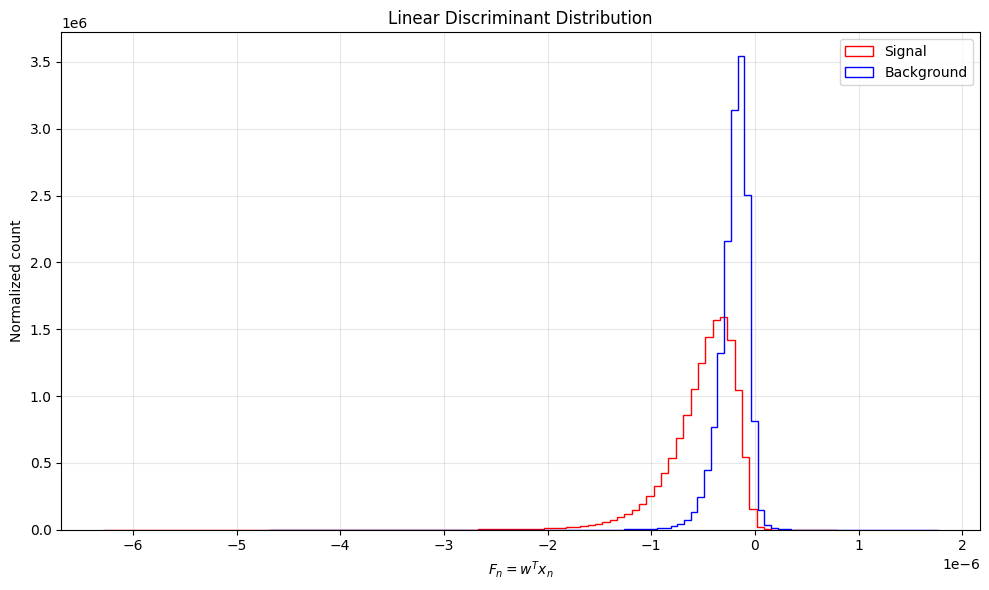

In [44]:
# Exercise 8.2: Compute w = S_W^{-1} (m2 - m1) and plot F_n distributions

# Use pseudo-inverse for stability (safer than inv)
w = np.linalg.pinv(S_W) @ (m2 - m1)

print("Linear coefficients w:")
for name, coeff in zip(feature_vars, w):
    print(f"{name:>15s}: {coeff:.6f}")

# Compute F_n = w^T x_n for signal and background
F_sig = X_sig @ w
F_bkg = X_bkg @ w

plt.figure(figsize=(10, 6))

plt.hist(F_sig, bins=100, histtype='step', color='red',
         label='Signal', density=True)

plt.hist(F_bkg, bins=100, histtype='step', color='blue',
         label='Background', density=True)

plt.xlabel('$F_n = w^T x_n$')
plt.ylabel('Normalized count')
plt.title('Linear Discriminant Distribution')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/f9/jsb45pg91jl516lqxkh0212m0000gn/T/ipykernel_27721/103956265.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_F = np.trapz(tpr_sorted, fpr_sorted)


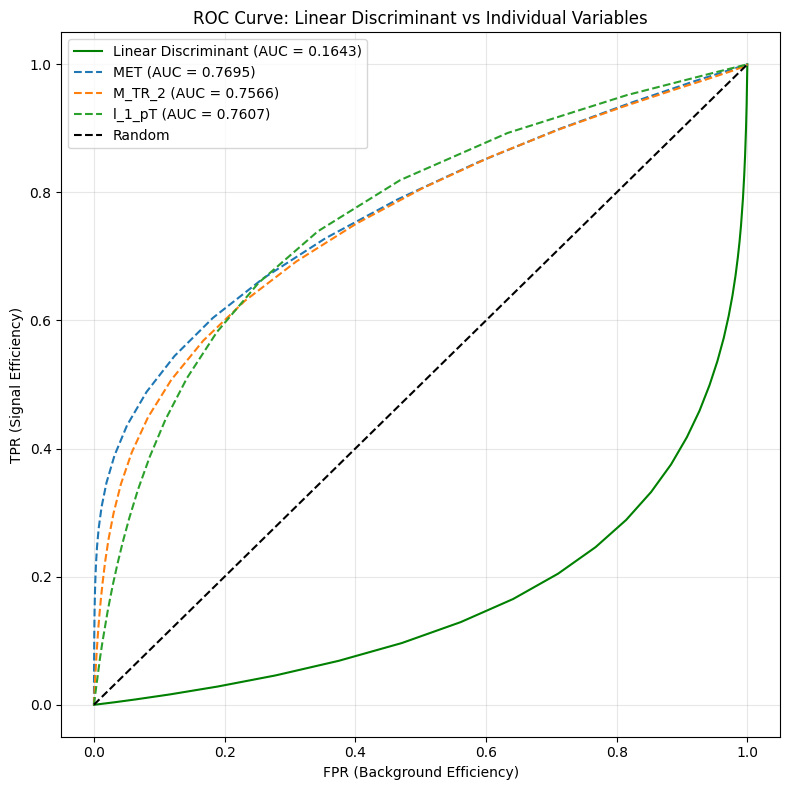

In [45]:
# Exercise 8.3: ROC curve for the linear discriminant F_n

thresholds_F = np.linspace(min(F_sig.min(), F_bkg.min()),
                           max(F_sig.max(), F_bkg.max()), 300)

tpr_F = []
fpr_F = []

for t in thresholds_F:
    tpr_F.append((F_sig > t).sum() / len(F_sig))
    fpr_F.append((F_bkg > t).sum() / len(F_bkg))

fpr_F = np.array(fpr_F)
tpr_F = np.array(tpr_F)

# Sort by FPR
order = np.argsort(fpr_F)
fpr_sorted = fpr_F[order]
tpr_sorted = tpr_F[order]

# Add endpoints
if fpr_sorted[0] > 0:
    fpr_sorted = np.insert(fpr_sorted, 0, 0.0)
    tpr_sorted = np.insert(tpr_sorted, 0, 0.0)

if fpr_sorted[-1] < 1:
    fpr_sorted = np.append(fpr_sorted, 1.0)
    tpr_sorted = np.append(tpr_sorted, 1.0)

# AUC
area_F = np.trapz(tpr_sorted, fpr_sorted)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr_sorted, tpr_sorted,
        label=f'Linear Discriminant (AUC = {area_F:.4f})',
        color='green')

# Overlay top 3 individual variable ROCs
for var in top3_vars:
    th = np.linspace(df[var].min(), df[var].max(), 200)
    
    t_vals = [(df_sig[var] > xc).sum() / len(df_sig) for xc in th]
    f_vals = [(df_bkg[var] > xc).sum() / len(df_bkg) for xc in th]
    
    sp = sorted(zip(f_vals, t_vals))
    
    f_sorted = [p[0] for p in sp]
    t_sorted = [p[1] for p in sp]
    
    area_v = auc(f_sorted, t_sorted)
    
    ax.plot(f_sorted, t_sorted, '--',
            label=f'{var} (AUC = {area_v:.4f})')

# Random line
ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_xlabel('FPR (Background Efficiency)')
ax.set_ylabel('TPR (Signal Efficiency)')
ax.set_title('ROC Curve: Linear Discriminant vs Individual Variables')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Exercise 8.4: Maximal significance using the linear discriminant for each scenario

scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

thresholds_F = np.linspace(min(F_sig.min(), F_bkg.min()),
                           max(F_sig.max(), F_bkg.max()), 500)

table_rows = []

for NS, NB in scenarios:
    best_sigma = 0.0
    best_tc = 0.0
    
    for tc in thresholds_F:
        eps_s = (F_sig > tc).sum() / len(F_sig)
        eps_b = (F_bkg > tc).sum() / len(F_bkg)
        
        Nsp = eps_s * NS
        Nbp = eps_b * NB
        
        sigma = Nsp / np.sqrt(Nsp + Nbp) if (Nsp + Nbp) > 0 else 0
        
        if sigma > best_sigma:
            best_sigma = sigma
            best_tc = tc
    
    table_rows.append([
        f"NS={NS}, NB={NB}",
        f"{best_tc:.4f}",
        f"{best_sigma:.4f}"
    ])

print("Maximal significance using the Linear Discriminant:")

display(HTML(tabulate.tabulate(
    table_rows,
    headers=["Scenario", "Optimal F_c", "Max σ_S'"],
    tablefmt="html"
)))

Maximal significance using the Linear Discriminant:


Scenario,Optimal F_c,Max σ_S'
"NS=10, NB=100",-0,0.9535
"NS=100, NB=1000",-0,3.0151
"NS=1000, NB=10000",-0,9.5346
"NS=10000, NB=100000",-0,30.1511
